# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
!git clone https://github.com/Team-TUD/CTAB-GAN-Plus
import sys
sys.path.append('./CTAB-GAN-Plus')
from model.ctabgan import CTABGAN

fatal: destination path 'CTAB-GAN-Plus' already exists and is not an empty directory.


Generating report ...

(1/2) Evaluating Column Shapes: |          | 0/12 [00:00<?, ?it/s]|

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 742.42it/s]|
Column Shapes Score: 70.36%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 307.23it/s]|
Column Pair Trends Score: 70.56%

Overall Score (Average): 70.46%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 730.87it/s]|
Column Shapes Score: 68.05%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 341.39it/s]|
Column Pair Trends Score: 49.12%

Overall Score (Average): 58.59%



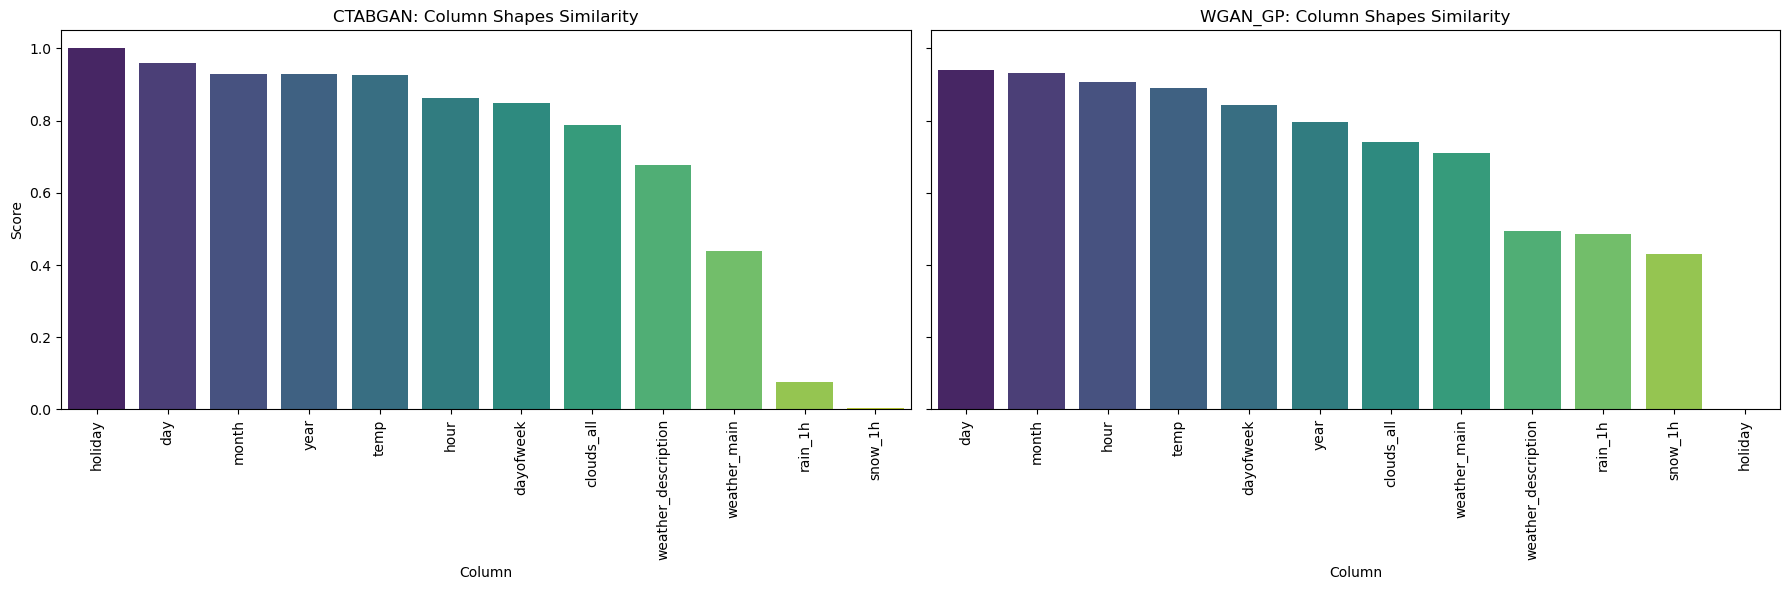

,Column,Metric,Score,Model
0,holiday,TVComplement,1.000,CTABGAN
1,day,KSComplement,0.960,CTABGAN
2,month,KSComplement,0.930,CTABGAN
3,year,TVComplement,0.928,CTABGAN
4,temp,KSComplement,0.926,CTABGAN
5,hour,KSComplement,0.863,CTABGAN
6,dayofweek,TVComplement,0.850,CTABGAN
7,clouds_all,KSComplement,0.789,CTABGAN
8,weather_description,TVComplement,0.677,CTABGAN
9,weather_main,TVComplement,0.440,CTABGAN


In [4]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "traffic_volume"

real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval[real_eval.columns]

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )

    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]

    sns.barplot(
        x="Column",
        y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )

    ax.set_title(f"{model_name}: Column Shapes Similarity")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)

display(combined_details.head(20))

# 1. Univariate Analysis

### 1.2. Jensen–Shannon divergence

In [5]:
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    real = pd.to_numeric(real, errors="coerce").dropna().to_numpy()
    synth = pd.to_numeric(synth, errors="coerce").dropna().to_numpy()

    if len(real) == 0 or len(synth) == 0:
        return np.array([0.5, 0.5]), np.array([0.5, 0.5])

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)

    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame, synth_df: pd.DataFrame, bins=30, normalize=True) -> pd.DataFrame:
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        if num_cols:
            scaler = MinMaxScaler()
            real[num_cols] = scaler.fit_transform(real[num_cols])
            synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        js_div = jensenshannon(p, q, base=2) ** 2
        results.append({"Feature": col, "JS_Divergence": float(js_div)})

    return pd.DataFrame(results).sort_values("JS_Divergence", ascending=False).reset_index(drop=True)

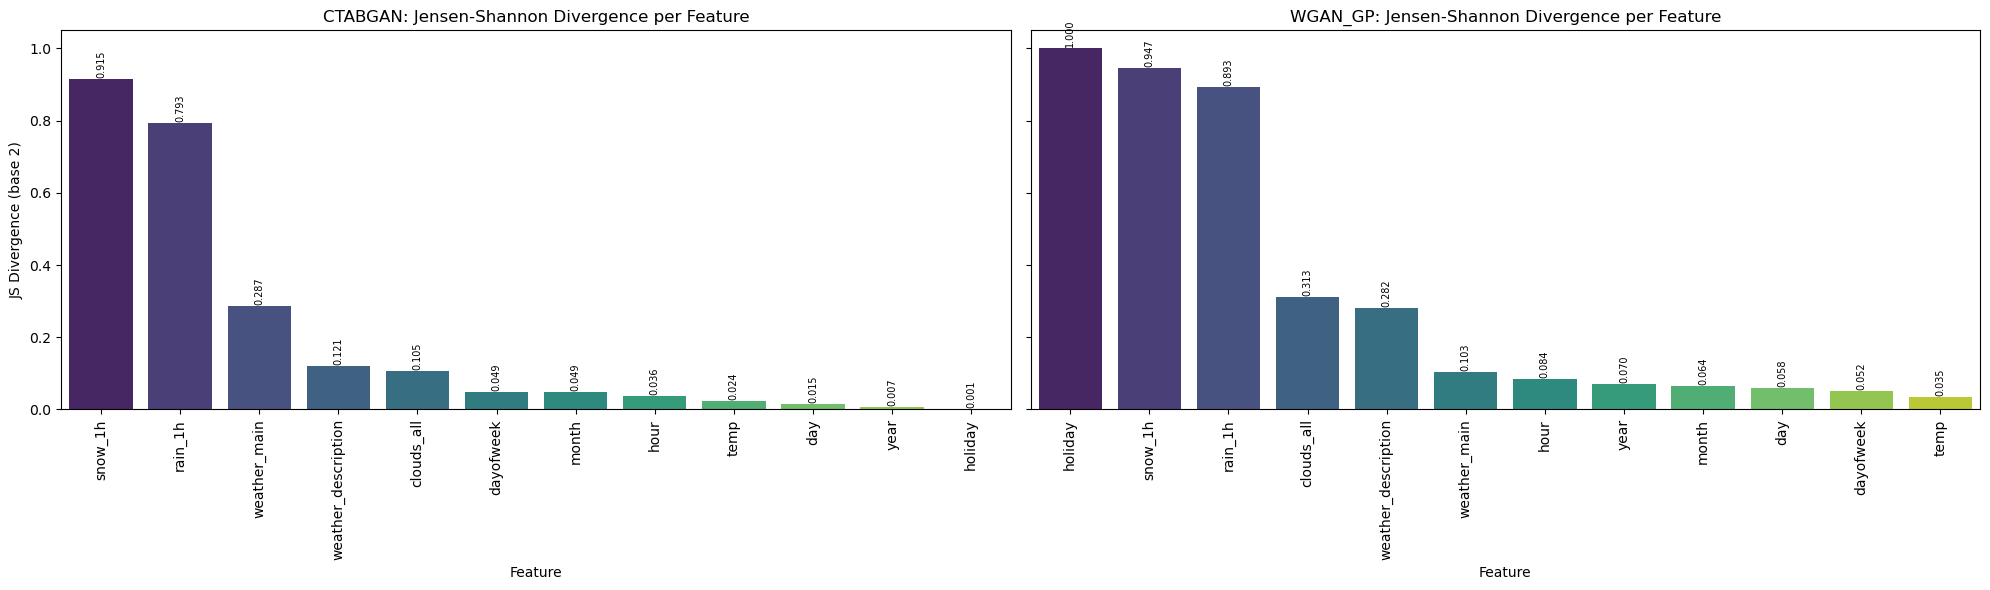

,Feature,JS_Divergence,Model
0,snow_1h,0.915272,CTABGAN
1,rain_1h,0.793295,CTABGAN
2,weather_main,0.287349,CTABGAN
3,weather_description,0.121490,CTABGAN
4,clouds_all,0.105335,CTABGAN
5,dayofweek,0.048961,CTABGAN
6,month,0.048810,CTABGAN
7,hour,0.036451,CTABGAN
8,temp,0.023752,CTABGAN
9,day,0.014967,CTABGAN


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "traffic_volume"

js_results_by_model = {}

for model_name in model_order:
    real_eval = data.drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore").copy()

    common_cols = real_eval.columns.intersection(synth_eval.columns)
    real_eval = real_eval[common_cols]
    synth_eval = synth_eval[common_cols]

    js_df = compute_js_divergence(
        real_eval,
        synth_eval,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)

    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]

    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)

display(all_js.head(20))

### 1.3 Wasserstein Distance



CTABGAN - Wasserstein Distance:
temp: 0.0258
rain_1h: 0.0040
snow_1h: 0.0037
clouds_all: 0.1374
year: 0.0220
month: 0.0257
day: 0.0179
hour: 0.0872
dayofweek: 0.0385

WGAN_GP - Wasserstein Distance:
temp: 0.0301
rain_1h: 0.0114
snow_1h: 0.0052
clouds_all: 0.1351
year: 0.0632
month: 0.0488
day: 0.0416
hour: 0.0610
dayofweek: 0.0538

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,CTABGAN,0.040253,0.025727,0.13740
1,WGAN_GP,0.050029,0.048818,0.13505


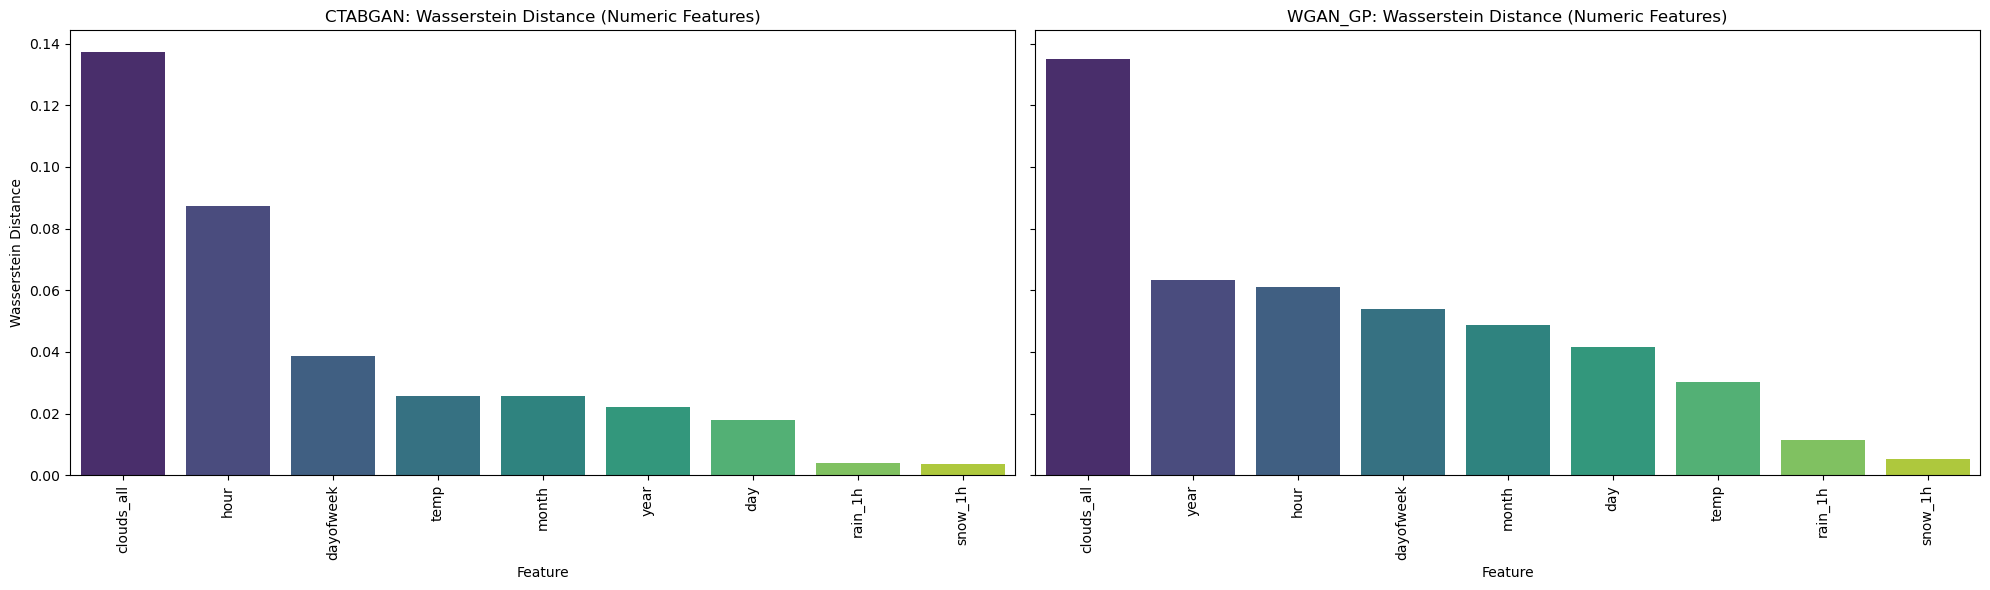

In [7]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "traffic_volume"

# Use numeric features only
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != target_col]

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data[feature_cols]),
    columns=feature_cols
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # Keep only columns available in both real and synthetic data
    common_feature_cols = [c for c in feature_cols if c in synth_df.columns]

    synth_num = synth_df[common_feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=common_feature_cols
    )

    real_scaled_common = real_scaled[common_feature_cols]

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")

    for col in common_feature_cols:
        dist = wasserstein_distance(real_scaled_common[col], synthetic_scaled[col])
        dists.append((col, float(dist)))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(
        dists,
        columns=["Feature", "Wasserstein_Distance"]
    ).sort_values("Wasserstein_Distance", ascending=False)

    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": float(dist_df["Wasserstein_Distance"].mean()),
        "Median_Wasserstein": float(dist_df["Wasserstein_Distance"].median()),
        "Max_Wasserstein": float(dist_df["Wasserstein_Distance"].max()),
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("Mean_Wasserstein")
    .reset_index(drop=True)
)

print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]

    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )

    ax.set_title(f"{model_name}: Wasserstein Distance (Numeric Features)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [8]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "traffic_volume"
date_col = "date_time"
drop_cols = [c for c in [target_col, date_col] if c in data.columns]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_outputs[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)

    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTABGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9125, Avg = 0.5733

Intra-set Similarity (Synthetic):
Max = 0.8942, Avg = 0.5982

Cross-set Similarity (Real vs Synthetic):
Max = 0.8986, Avg = 0.5752

WGAN_GP - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9125, Avg = 0.5733

Intra-set Similarity (Synthetic):
Max = 0.9744, Avg = 0.7215

Cross-set Similarity (Real vs Synthetic):
Max = 0.9028, Avg = 0.6572


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTABGAN,0.91246,0.573318,0.894150,0.598227,0.898633,0.575214
1,WGAN_GP,0.91246,0.573318,0.974421,0.721548,0.902846,0.657231


### 1.5 t-SNE Visualization


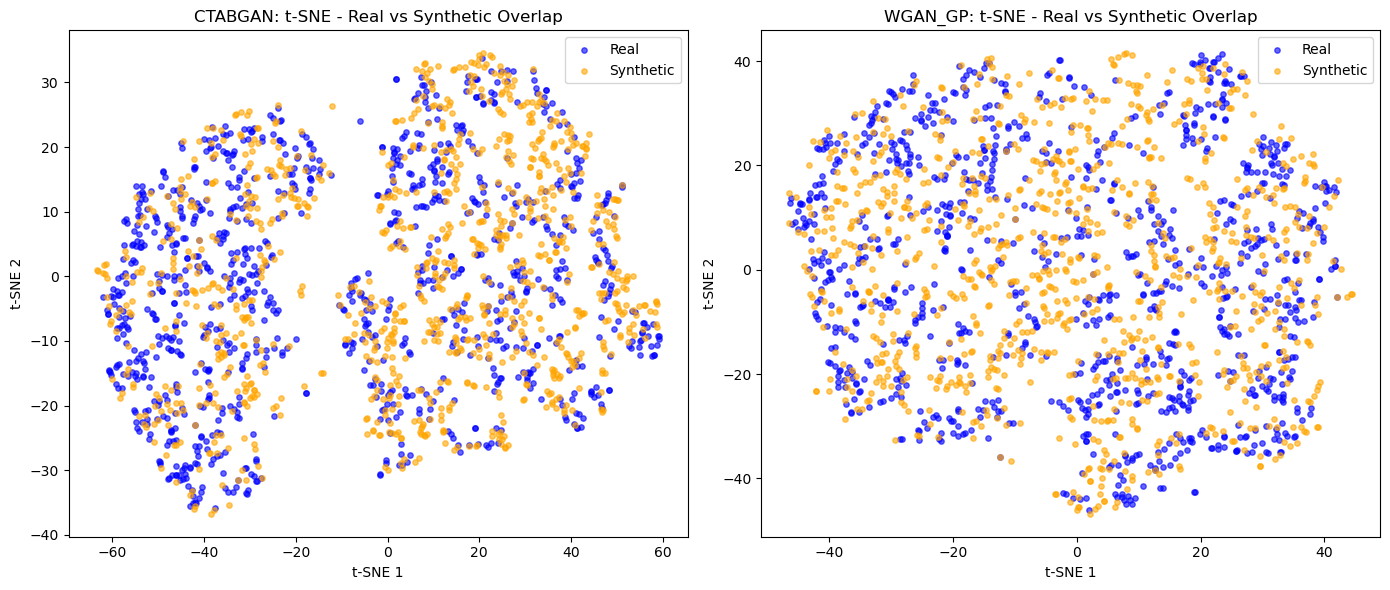

In [9]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "traffic_volume"
date_col = "date_time"

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_num = data[feature_cols].copy()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_num),
    columns=feature_cols
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_outputs[model_name].copy()

    common_feature_cols = [c for c in feature_cols if c in synth_df.columns]

    synth_num = synth_df[common_feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=common_feature_cols
    )

    real_scaled_common = real_scaled[common_feature_cols]

    combined = np.vstack([
        real_scaled_common.values,
        synthetic_scaled.values
    ])

    labels = np.array(
        ["Real"] * len(real_scaled_common) +
        ["Synthetic"] * len(synthetic_scaled)
    )

    tsne = TSNE(
        n_components=2,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )

    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue",
        alpha=0.6,
        s=15,
        label="Real"
    )

    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange",
        alpha=0.6,
        s=15,
        label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()


### 1.6 MMD (Maximum Mean Discrepancy)


In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "traffic_volume"
date_col = "date_time"

drop_cols = [c for c in [target_col, date_col] if c in data.columns]
real_features = data.drop(columns=drop_cols, errors="ignore").copy()

# Keep numeric only for RBF MMD
real_features = real_features.select_dtypes(include=[np.number]).copy()

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)

    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)

    mmd_results.append({
        "Model": model_name,
        "MMD_Score": float(mmd_score)
    })

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = (
    pd.DataFrame(mmd_results)
    .sort_values("MMD_Score")
    .reset_index(drop=True)
)

print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTABGAN - MMD score: 0.010479
WGAN_GP - MMD score: 0.002110

MMD comparison (lower is better):


,Model,MMD_Score
0,WGAN_GP,0.002110
1,CTABGAN,0.010479


### 1.7 Cosine Similarity


In [11]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "traffic_volume"
date_col = "date_time"
drop_cols = [c for c in [target_col, date_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

similarity_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)

    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)

    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = (
    pd.DataFrame(similarity_results)
    .sort_values("Average_Cosine_Similarity", ascending=False)
    .reset_index(drop=True)
)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTABGAN - Sample-Level Similarity:
Average cosine similarity: 0.0004
Maximum cosine similarity: 0.9966

WGAN_GP - Sample-Level Similarity:
Average cosine similarity: 0.0033
Maximum cosine similarity: 0.9930

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,WGAN_GP,0.003326,0.992976
1,CTABGAN,0.000365,0.996612


### 1.8 Nearest Neighbours 


In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "traffic_volume"
date_col = "date_time"
drop_cols = [c for c in [target_col, date_col] if c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)

    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = (
    pd.DataFrame(privacy_rows)
    .sort_values("Avg_NN_Distance", ascending=False)
    .reset_index(drop=True)
)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTABGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.1311
Minimum NN Distance (Synthetic -> Real): 0.2504
5th Percentile NN Distance: 0.6705

WGAN_GP - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.1324
Minimum NN Distance (Synthetic -> Real): 0.2718
5th Percentile NN Distance: 0.7119

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,WGAN_GP,1.132352,0.271796,0.711877
1,CTABGAN,1.131128,0.250407,0.670465


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTABGAN,10.002244,7.368421,19.334128
1,WGAN_GP,23.211840,2.923091,22.287039


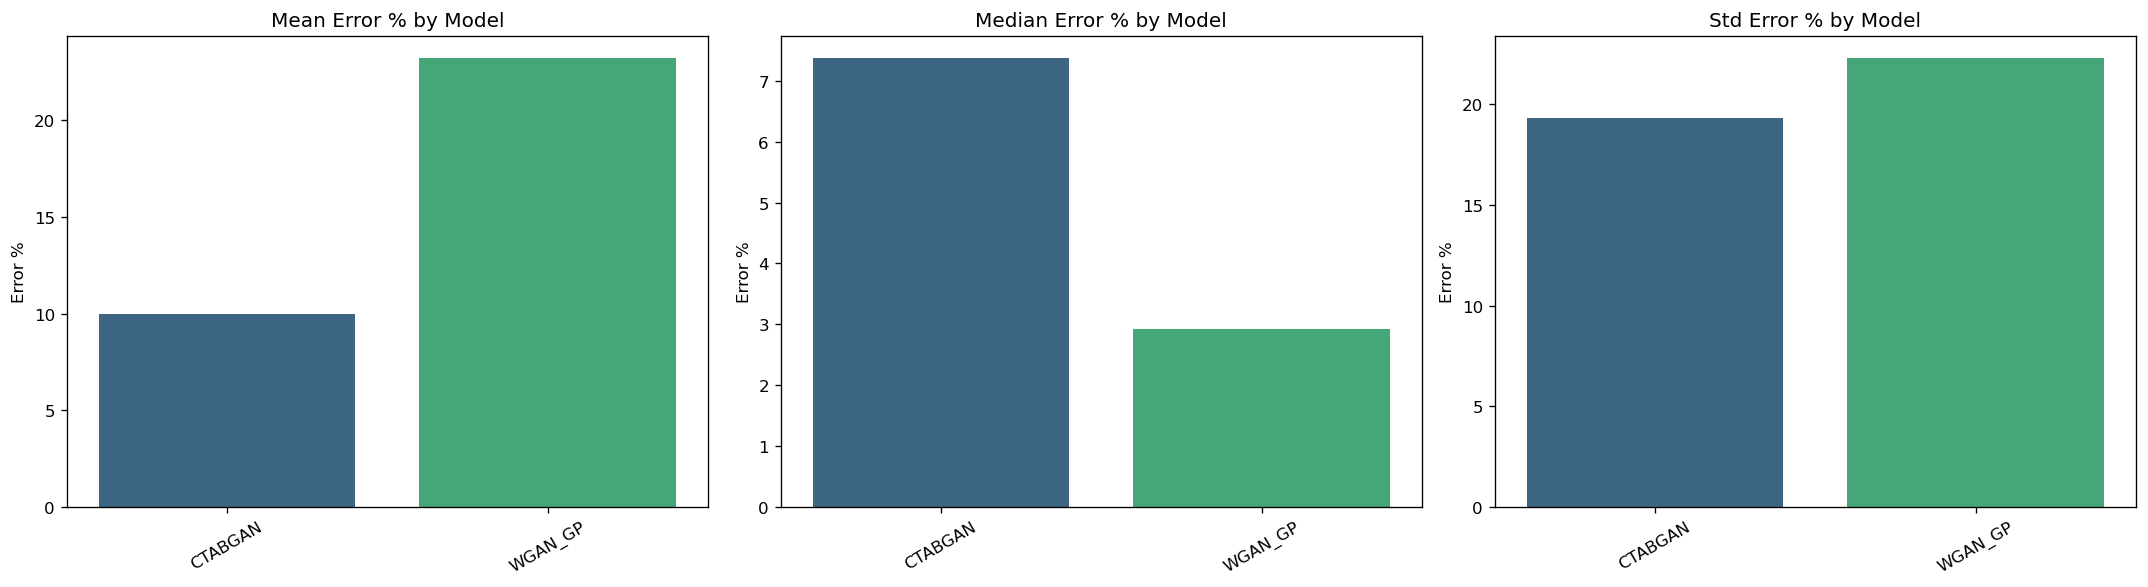

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "traffic_volume"

real_df = data.copy()

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    common_num_cols = [c for c in num_cols if c in synth_df.columns]

    real_means = real_df[common_num_cols].astype(np.float64).mean()
    synth_means = synth_df[common_num_cols].astype(np.float64).mean()

    real_stds = real_df[common_num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[common_num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (
        np.abs(synth_means - real_means) /
        real_means.replace(0, np.nan).abs()
    ) * 100.0

    std_error_pct = (
        np.abs(synth_stds - real_stds) /
        real_stds.replace(0, np.nan).abs()
    ) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": common_num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(
    data=summary_df,
    x="Model",
    y="Mean Error %",
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=summary_df,
    x="Model",
    y="Median Error %",
    ax=axes[1],
    palette="viridis"
)
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(
    data=summary_df,
    x="Model",
    y="Std Error %",
    ax=axes[2],
    palette="viridis"
)
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

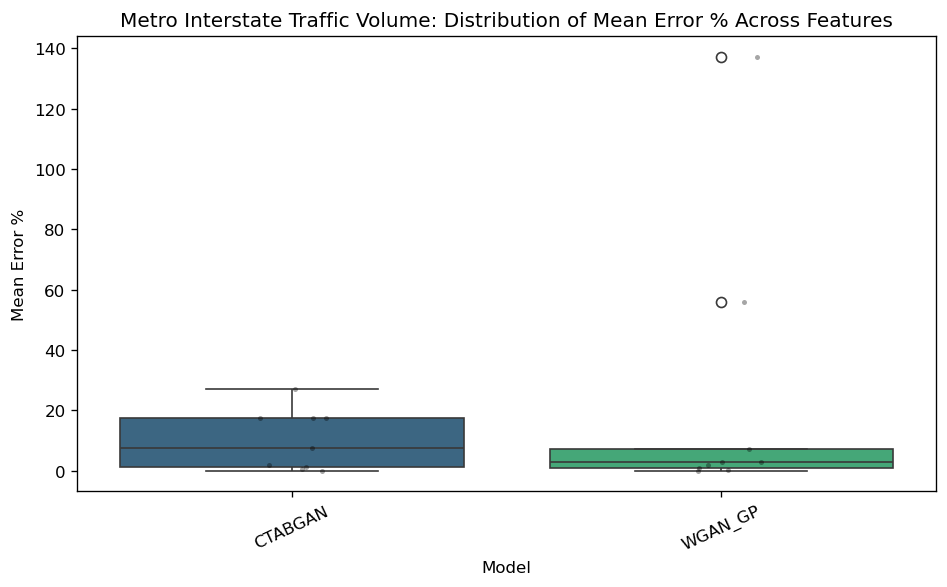

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_order
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(8, 5), dpi=120)

sns.boxplot(
    data=dist_df,
    x="Model",
    y="Mean_Error_%",
    palette="viridis"
)

sns.stripplot(
    data=dist_df,
    x="Model",
    y="Mean_Error_%",
    color="black",
    alpha=0.35,
    size=3
)

plt.title("Metro Interstate Traffic Volume: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

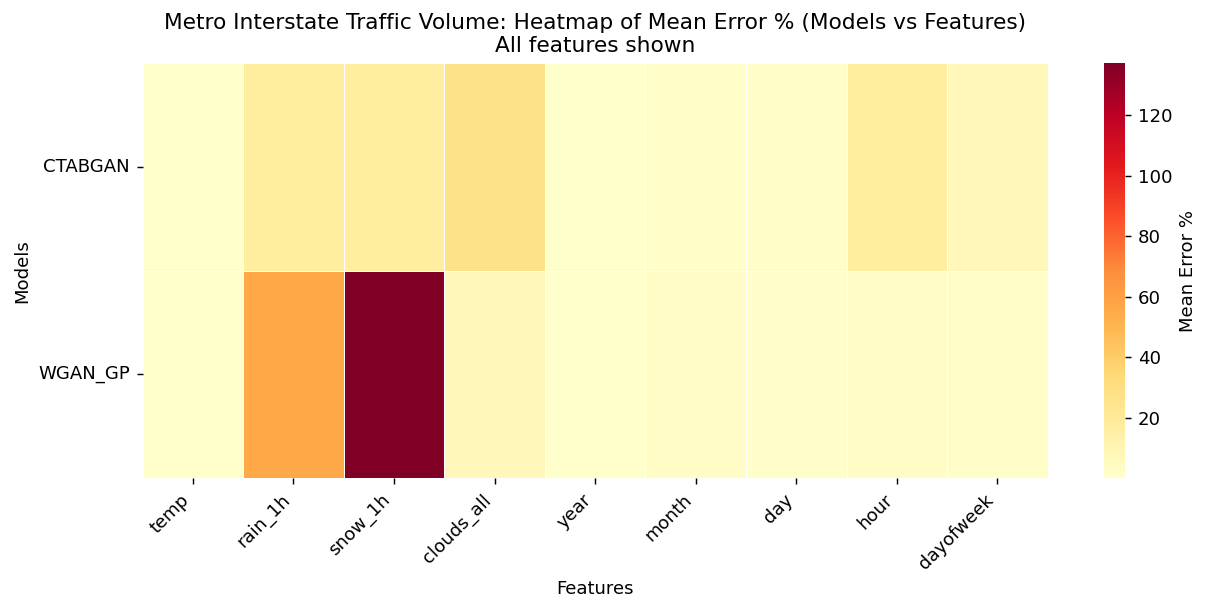

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20

if heatmap_df.shape[1] > max_features:
    top_features = (
        heatmap_df
        .mean(axis=0, skipna=True)
        .sort_values(ascending=False)
        .head(max_features)
        .index
    )
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [
    truncate_label(c, max_len=18)
    for c in heatmap_plot_df.columns
]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)

sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(
    "Metro Interstate Traffic Volume: Heatmap of Mean Error % "
    f"(Models vs Features)\n{truncated_note}"
)
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(
    np.arange(len(display_labels)) + 0.5,
    display_labels,
    rotation=45,
    ha="right"
)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [17]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_metro(real_df, synth_df, target="traffic_volume", date_col="date_time"):
    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c not in [target]]

    scaler = MinMaxScaler()

    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    if target in real_scaled.columns and target in synth_scaled.columns:
        # Compare each feature's relationship with target using rank correlation difference
        for col in num_cols:
            r_rel = real_scaled[[col, target]].corr(method="spearman").iloc[0, 1]
            s_rel = synth_scaled[[col, target]].corr(method="spearman").iloc[0, 1]
            results_target.append({
                "feature": col,
                "delta_target_relation": abs(r_rel - s_rel)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = (
        pd.DataFrame(results_target).sort_values("delta_target_relation", ascending=False)
        if results_target else
        pd.DataFrame(columns=["feature", "delta_target_relation"])
    )

    return corr_df, target_df

In [18]:
import pandas as pd

model_order = ["CTABGAN", "WGAN_GP"]
real_df = data.copy()

target_col = "traffic_volume"
date_col = "date_time"

if "bivariate_quality_metro" in globals():
    quality_fn = bivariate_quality_metro
elif "bivariate_quality_heart" in globals():
    quality_fn = bivariate_quality_heart
elif "bivariate_quality_cancer" in globals():
    quality_fn = bivariate_quality_cancer
else:
    raise NameError(
        "Define `bivariate_quality_metro` before running this cell."
    )

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    common_cols = real_df.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]
    real_aligned = real_df[common_cols]

    real_eval = real_aligned.drop(columns=[date_col], errors="ignore")
    synth_eval = synth_df.drop(columns=[date_col], errors="ignore")

    corr_results, target_results = quality_fn(
        real_df=real_eval,
        synth_df=synth_eval
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))

    print("=" * 60)
    print(f"{model_name} - Features that differ most by relation to {target_col}:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next(
        (
            c for c in [
                "AbsDiff",
                "abs_diff",
                "Difference",
                "diff",
                "delta_corr"
            ]
            if c in corr_results.columns
        ),
        None
    )

    target_metric_col = next(
        (
            c for c in [
                "AbsDiff",
                "abs_diff",
                "Difference",
                "diff",
                "delta_target_relation",
                "delta_wasserstein"
            ]
            if c in target_results.columns
        ),
        None
    )

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


CTABGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
4,temp,month,0.244580
0,temp,rain_1h,0.176154
26,year,month,0.165267
25,clouds_all,dayofweek,0.144040
13,rain_1h,hour,0.143483
6,temp,hour,0.123519
3,temp,year,0.109175
5,temp,day,0.107462
15,snow_1h,clouds_all,0.102483
9,rain_1h,clouds_all,0.087143


CTABGAN - Features that differ most by relation to traffic_volume:


,feature,delta_target_relation
7,hour,0.374607
8,dayofweek,0.088157
0,temp,0.087841
5,month,0.082389
6,day,0.073573
2,snow_1h,0.067942
1,rain_1h,0.042332
4,year,0.032178
3,clouds_all,0.016199



WGAN_GP - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
8,rain_1h,snow_1h,0.386903
17,snow_1h,month,0.188495
1,temp,snow_1h,0.101500
16,snow_1h,year,0.078745
11,rain_1h,month,0.076447
0,temp,rain_1h,0.073320
9,rain_1h,clouds_all,0.059283
30,month,day,0.057127
22,clouds_all,month,0.051037
20,snow_1h,dayofweek,0.049478


WGAN_GP - Features that differ most by relation to traffic_volume:


,feature,delta_target_relation
7,hour,0.121633
1,rain_1h,0.078433
5,month,0.052546
2,snow_1h,0.048313
4,year,0.034897
0,temp,0.031698
8,dayofweek,0.022521
6,day,0.004654
3,clouds_all,0.003269


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTABGAN,0.244580,0.140331,0.374607,0.096135
1,WGAN_GP,0.386903,0.112233,0.121633,0.044218


### 3 Multivariate Analysis


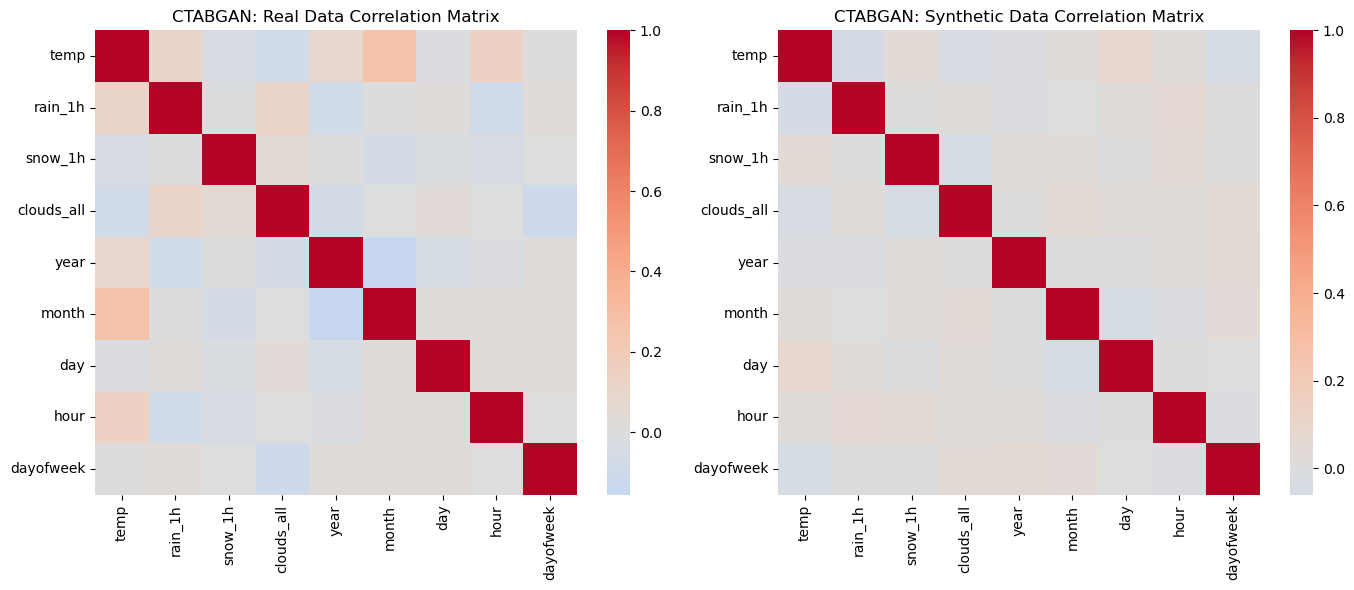

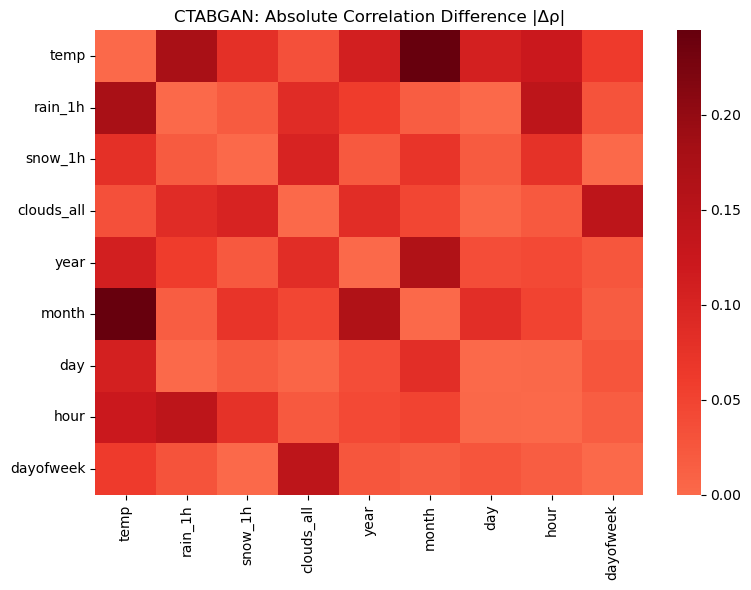

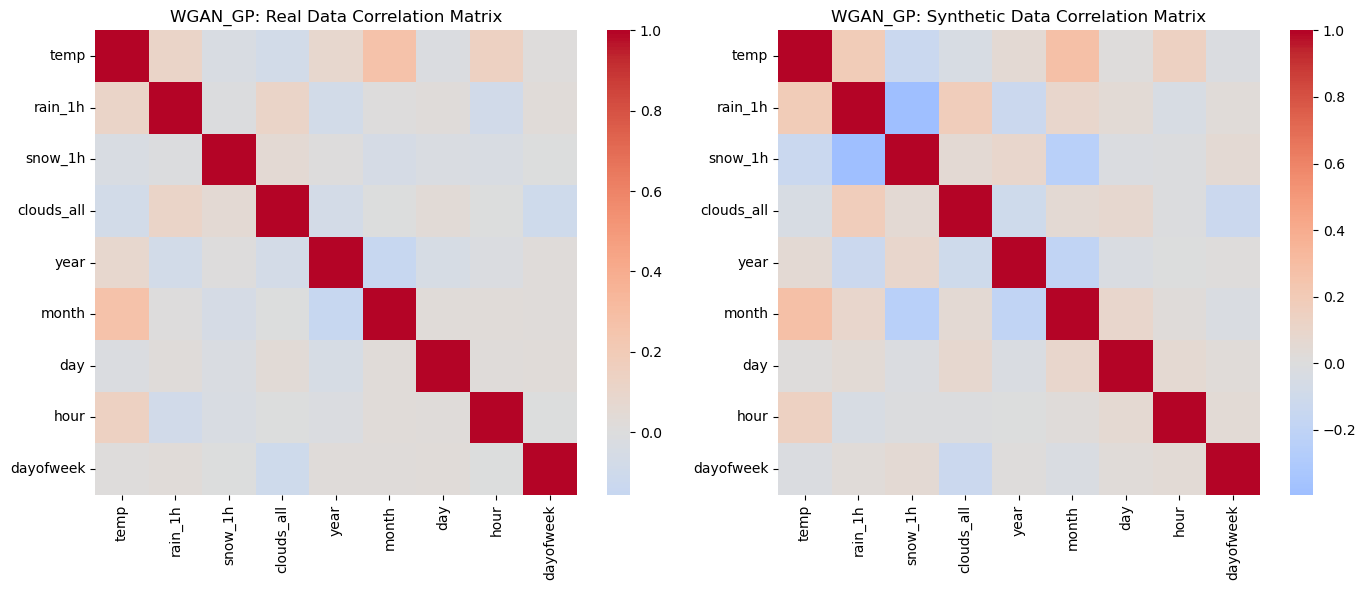

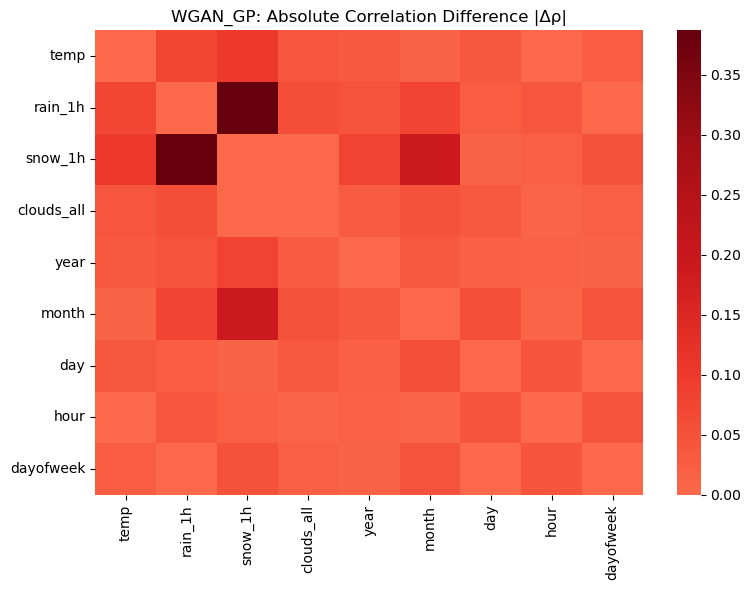

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]

real_df = data.copy()
target_col = "traffic_volume"

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    common_num_cols = [c for c in num_cols if c in synth_df.columns]

    real_corr = real_df[common_num_cols].corr()
    synth_corr = synth_df[common_num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(
        real_corr,
        cmap="coolwarm",
        center=0,
        ax=axes[0]
    )
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(
        synth_corr,
        cmap="coolwarm",
        center=0,
        ax=axes[1]
    )
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        diff_corr,
        cmap="Reds",
        center=0
    )
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()


CTABGAN - Global MMD (RBF): 0.009604


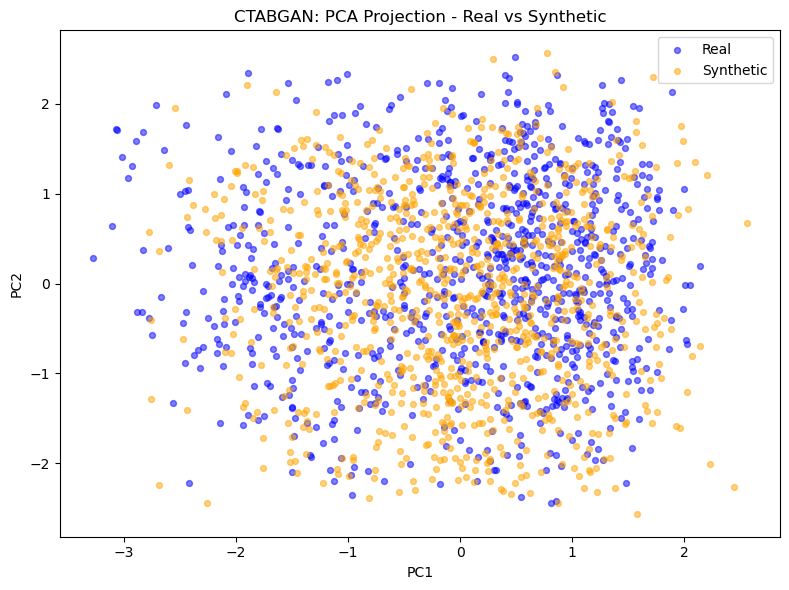

CTABGAN - Two-Sample Classifier Accuracy: 1.0000

WGAN_GP - Global MMD (RBF): 0.001288


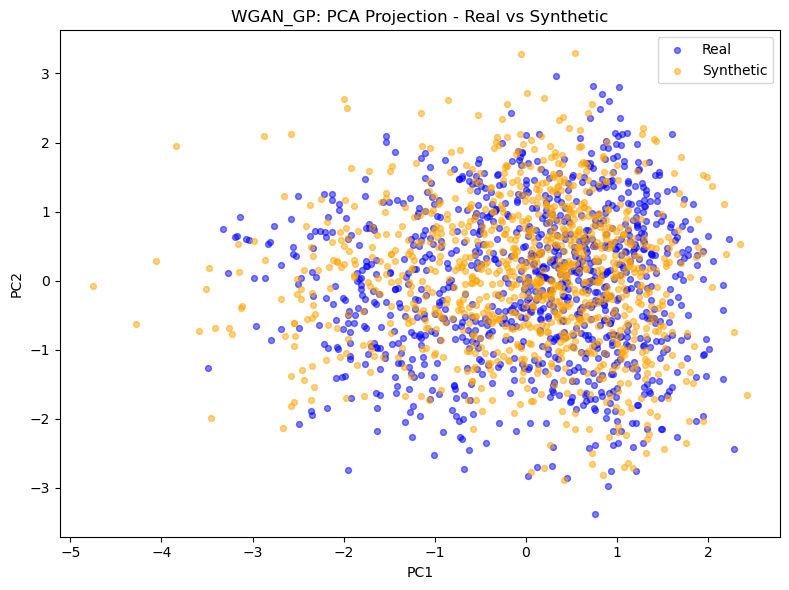

WGAN_GP - Two-Sample Classifier Accuracy: 1.0000

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,WGAN_GP,0.001288,1.0
1,CTABGAN,0.009604,1.0


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500):
    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = np.random.default_rng(42).choice(n, size=k, replace=False)
        Zs = Z[idx]
        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    n, m = len(X), len(Y)

    return (
        ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))) +
        ((Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))) -
        2 * Kxy.mean()
    )

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "traffic_volume"
date_col = "date_time"

drop_cols = [c for c in [target_col, date_col] if c in data.columns]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
X_real_df = X_real_df.select_dtypes(include=[np.number]).copy()

results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    X_synth_df = X_synth_df.select_dtypes(include=[np.number]).copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)

    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)

    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(
        ["Real"] * len(X_real_scaled) +
        ["Synthetic"] * len(X_synth_scaled)
    )

    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X_pca[labels == "Real", 0],
        X_pca[labels == "Real", 1],
        color="blue",
        alpha=0.5,
        label="Real",
        s=18
    )

    plt.scatter(
        X_pca[labels == "Synthetic", 0],
        X_pca[labels == "Synthetic", 1],
        color="orange",
        alpha=0.5,
        label="Synthetic",
        s=18
    )

    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))

    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st,
        y_c2st,
        test_size=0.3,
        stratify=y_c2st,
        random_state=42
    )

    clf = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = r2_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Global_MMD_RBF")
    .reset_index(drop=True)
)

print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 regression models 

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'SVR-RBF': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(max_iter=2000, random_state=42)
}

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_models(train_df, test_df, label, models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label]).copy()
    y_train = train_df[label].copy()

    X_test = test_df.drop(columns=[label]).copy()
    y_test = test_df[label].copy()

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed
    )
    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed
    )

    num_cols = X_train.select_dtypes(include=[np.number]).columns

    X_train = X_train[num_cols].astype(np.float64)
    X_test = X_test[num_cols].astype(np.float64)

    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        results.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R2": r2_score(y_test, preds)
        })

    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


CTABGAN - TSTR


,Model,MAE,RMSE,R2
0,ExtraTrees,1861.295030,2090.016547,-0.049131
1,RandomForest,1889.618643,2102.180789,-0.061378
2,SVR-RBF,1899.641277,2129.166988,-0.088804
3,KNN,1862.963514,2174.290283,-0.135443
4,GradientBoost,1940.048590,2320.156585,-0.292899
5,DecisionTree,2381.266604,2887.319850,-1.002257
6,ElasticNet,2010.591061,2927.134842,-1.057859
7,Lasso,2070.502314,3585.329929,-2.087368
8,Ridge,2074.205006,3631.675113,-2.167700
9,LinearRegression,2074.420363,3634.169100,-2.172053


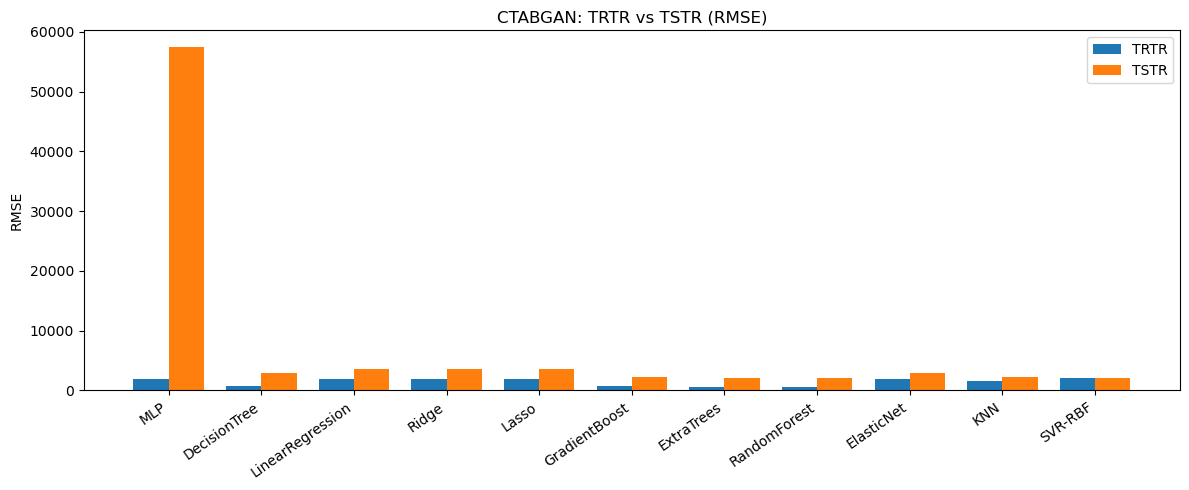

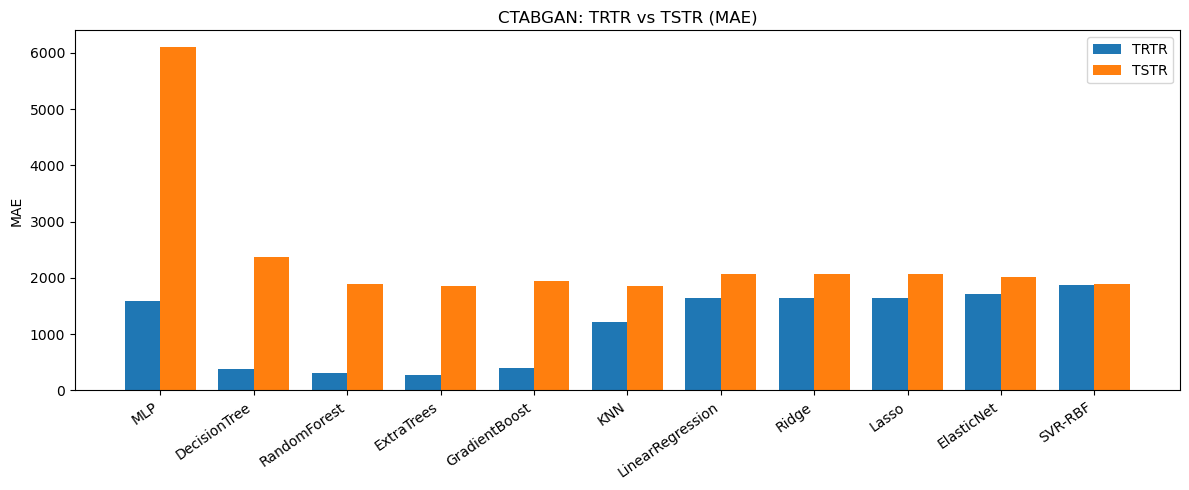

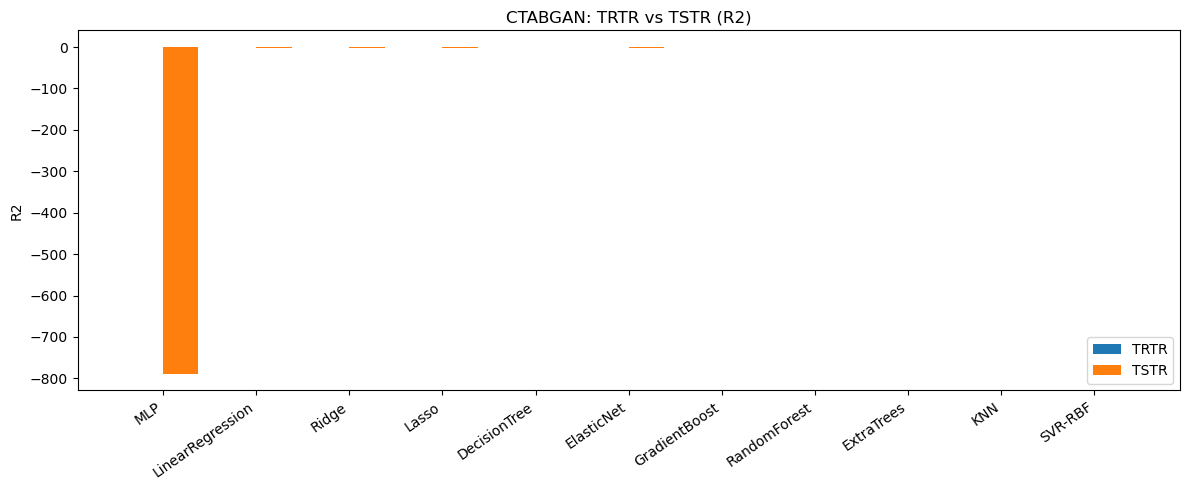

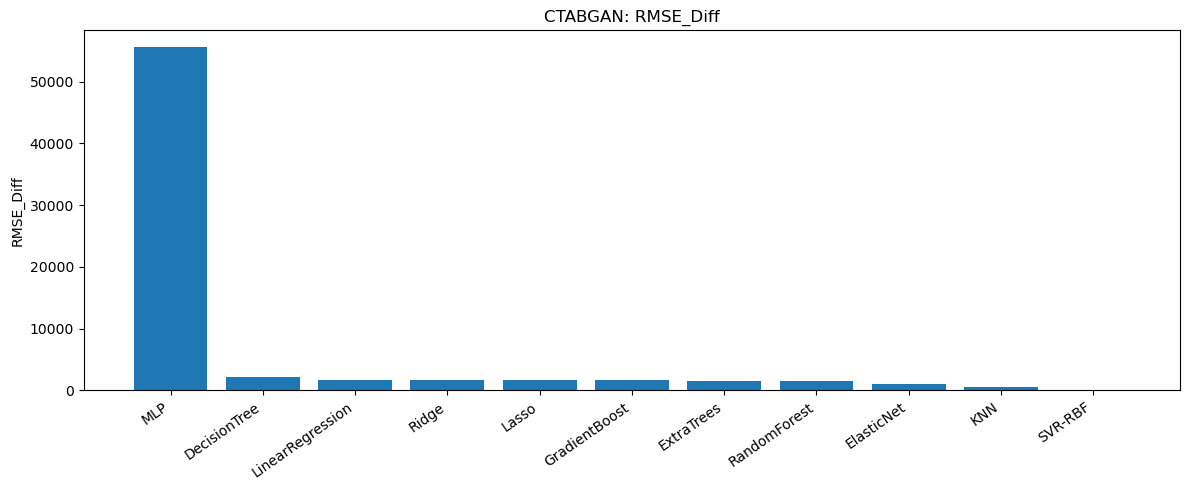

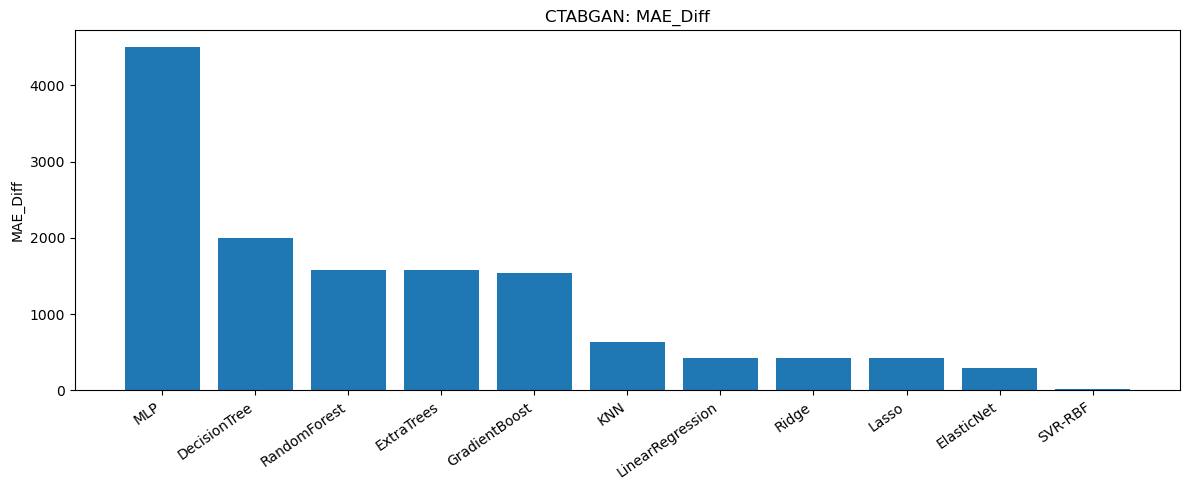

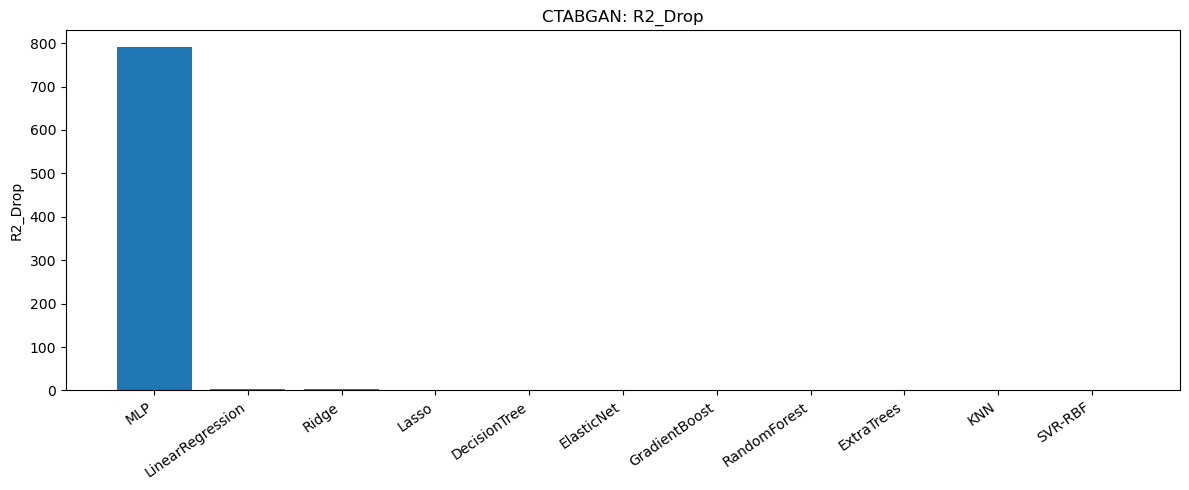


WGAN_GP - TSTR


,Model,MAE,RMSE,R2
0,GradientBoost,1037.717266,1302.622463,0.592463
1,ExtraTrees,1050.253100,1330.897548,0.574579
2,RandomForest,1079.357750,1341.797670,0.567582
3,KNN,1288.908000,1545.016053,0.426681
4,DecisionTree,1365.905000,1736.208811,0.276008
5,ElasticNet,1736.138233,1900.124344,0.132850
6,Lasso,1735.511446,1983.350874,0.055223
7,Ridge,1738.087007,1992.716220,0.046280
8,LinearRegression,1738.186994,1993.580777,0.045452
9,SVR-RBF,1858.543960,2045.630334,-0.005042


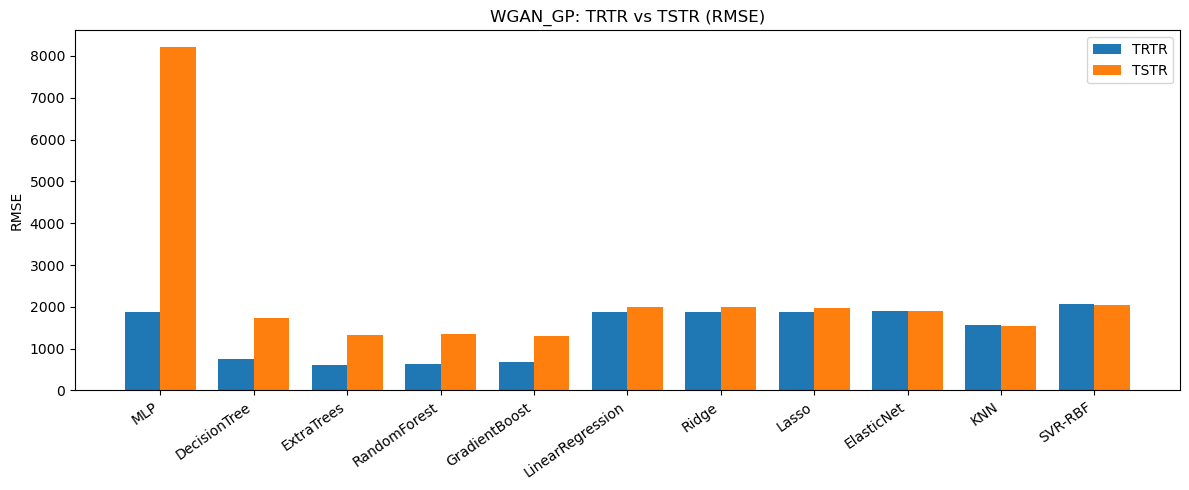

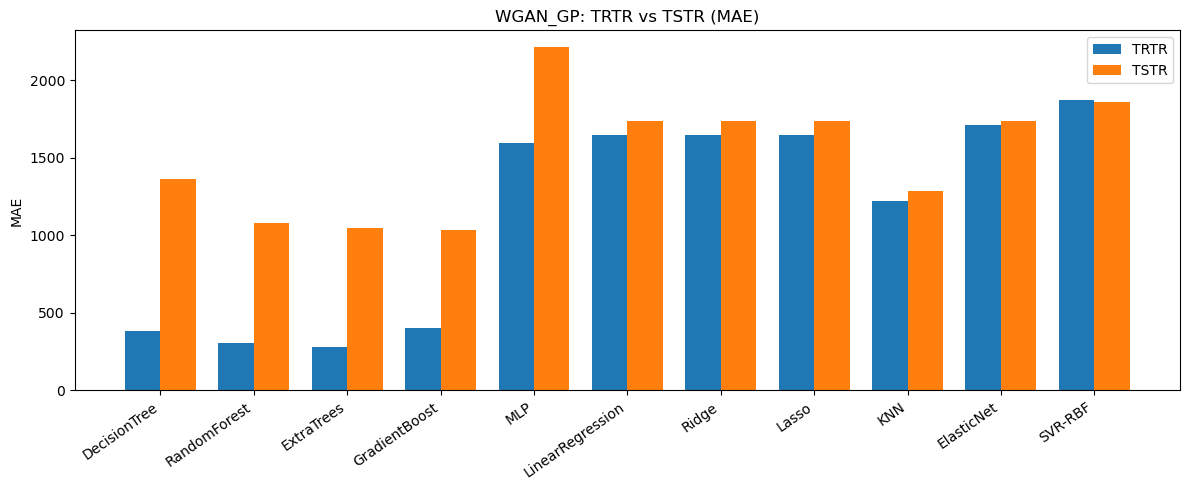

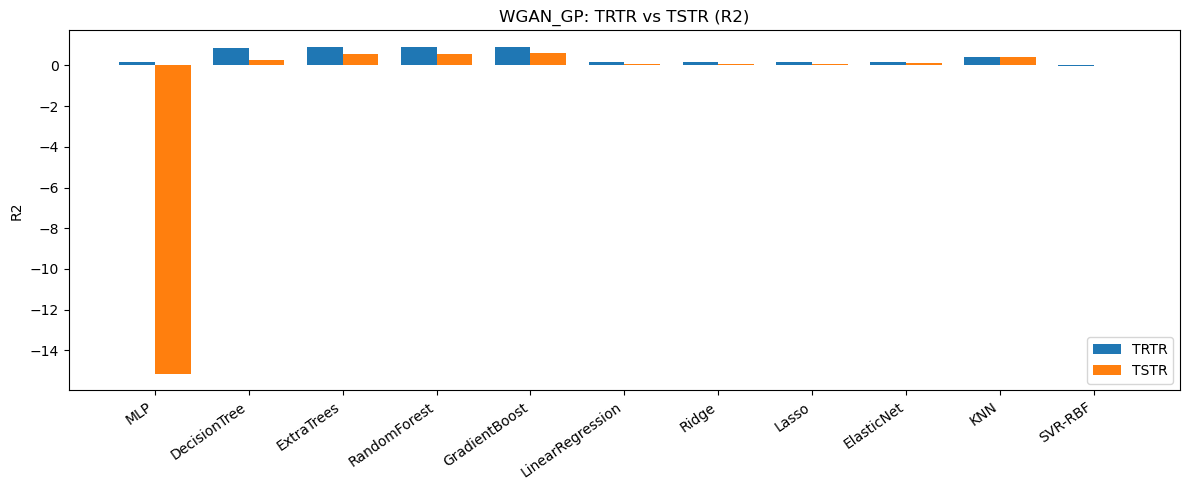

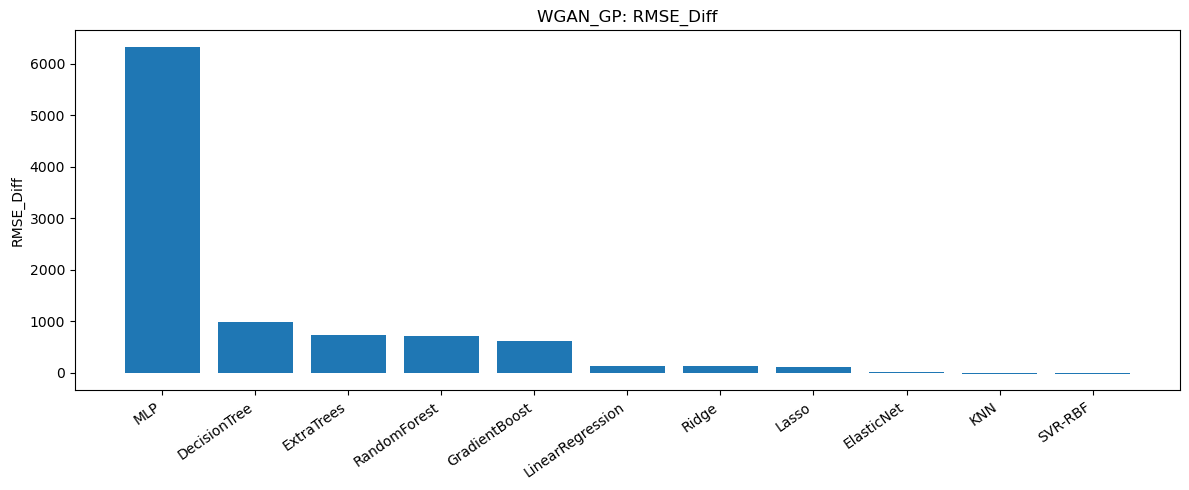

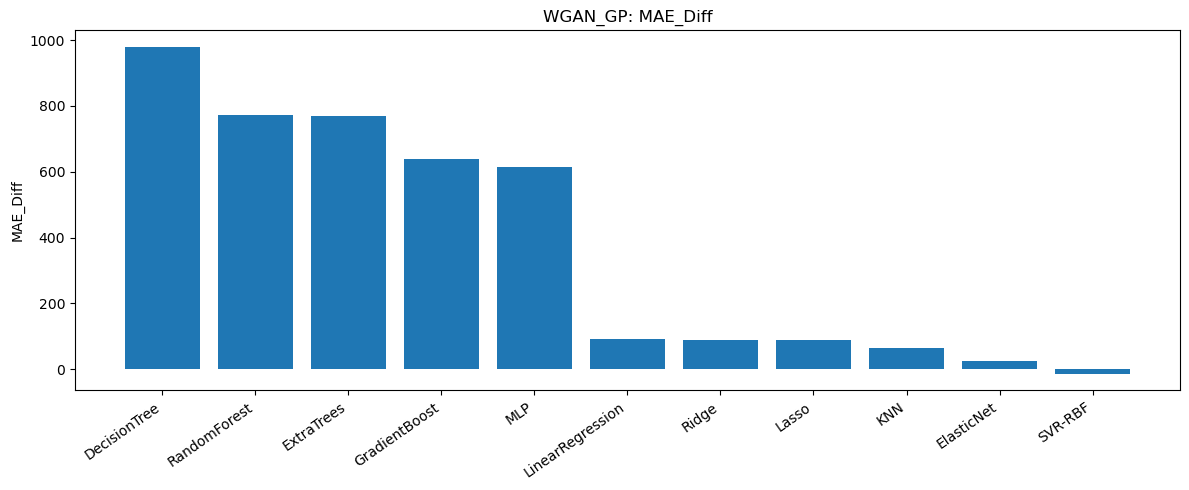

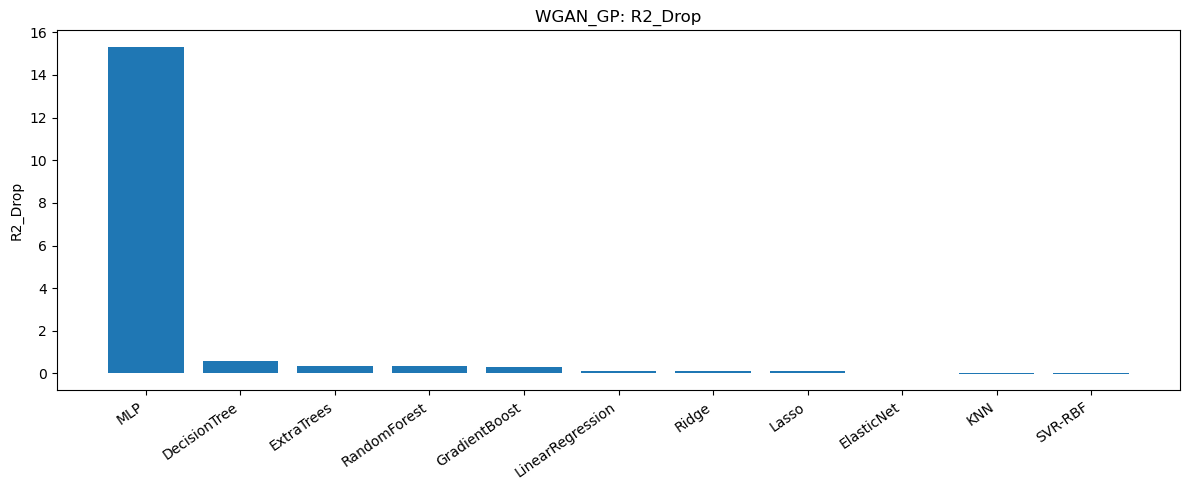


Average metric gap by synthetic generator:


,Synthetic_Model,RMSE_Diff,MAE_Diff,R2_Drop
1,WGAN_GP,880.719956,373.721539,1.561716
0,CTABGAN,6288.811725,1220.998456,73.062005


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

label_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="RMSE"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    if metric in ["MAE", "RMSE"]:
        df["Diff"] = df[f"{metric}_TSTR"] - df[f"{metric}_TRTR"]
    else:
        df["Diff"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]

    df = df.sort_values("Diff", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label="TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label="TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_diff(comparison_df, synth_name, metric):
    if metric not in comparison_df.columns:
        return

    df = comparison_df.sort_values(metric, ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[metric])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: {metric}")
    plt.tight_layout()
    plt.show()

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label=label_col,
    models=models
)

all_comp = []

for synth_name in model_order:
    synth_train = synthetic_outputs[synth_name].copy()

    common_cols = data.columns.intersection(synth_train.columns)
    synth_train = synth_train[common_cols]
    real_test = data[common_cols]

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=real_test,
        label=label_col,
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results,
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name

    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["RMSE", "MAE", "R2"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric)

    for diff_metric in ["RMSE_Diff", "MAE_Diff", "R2_Drop"]:
        plot_metric_diff(comparison, synth_name, diff_metric)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_gap = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[["RMSE_Diff", "MAE_Diff", "R2_Drop"]]
    .mean()
    .sort_values("RMSE_Diff")
)

print("\nAverage metric gap by synthetic generator:")
display(summary_gap)

In [24]:
import time
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

label_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def pick_10_models(models_dict):
    keys = list(models_dict.keys())
    if len(keys) < 10:
        raise ValueError(f"`models` has only {len(keys)} models; need at least 10.")
    return {k: clone(models_dict[k]) for k in keys[:10]}

def run_reg_models(X_train, y_train, X_test, y_test, models_dict):
    scaler = StandardScaler().fit(X_train)

    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []

    for name, reg in models_dict.items():
        t0 = time.time()

        m = clone(reg)
        m.fit(X_train_s, y_train)
        y_pred = m.predict(X_test_s)

        rows.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
            "FitSec": round(time.time() - t0, 3),
        })

    return pd.DataFrame(rows)

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != label_col]

X_real = data[feature_cols].to_numpy(dtype=np.float32)
y_real = data[label_col].to_numpy(dtype=np.float32)

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    random_state=42
)

models_used = pick_10_models(models)
print(f"Using {len(models_used)} models: {list(models_used.keys())}")

trtr_results = run_reg_models(
    X_train_real,
    y_train_real,
    X_test_real,
    y_test_real,
    models_used
)

all_comparisons = []

for synth_name in model_order:
    synth_df = synthetic_outputs[synth_name].copy()

    common_feature_cols = [c for c in feature_cols if c in synth_df.columns]

    X_synth = synth_df[common_feature_cols].to_numpy(dtype=np.float32)
    y_synth = synth_df[label_col].to_numpy(dtype=np.float32)

    X_test_common = pd.DataFrame(
        X_test_real,
        columns=feature_cols
    )[common_feature_cols].to_numpy(dtype=np.float32)

    tstr_results = run_reg_models(
        X_synth,
        y_synth,
        X_test_common,
        y_test_real,
        models_used
    )

    comparison = trtr_results.merge(
        tstr_results,
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[["MAE_Diff", "RMSE_Diff", "R2_Drop"]]
    .mean()
    .sort_values("RMSE_Diff")
)

print("Average performance gap by synthetic generator (lower is better):")
display(summary)

print("\nPer-model timing (seconds):")
timing_cols = [c for c in combined_comparison.columns if "FitSec" in c]

display(
    combined_comparison[
        ["Synthetic_Model", "Model"] + timing_cols
    ].sort_values(timing_cols[-1], ascending=False)
)

Using 10 models: ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'SVR-RBF', 'KNN', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoost']
Average performance gap by synthetic generator (lower is better):


,Synthetic_Model,MAE_Diff,RMSE_Diff,R2_Drop
1,WGAN_GP,361.967950,392.338358,0.247165
0,CTABGAN,892.954825,1685.863797,1.989824



Per-model timing (seconds):


,Synthetic_Model,Model,FitSec_TRTR,FitSec_TSTR
17,WGAN_GP,RandomForest,0.234,0.461
7,CTABGAN,RandomForest,0.234,0.427
8,CTABGAN,ExtraTrees,0.167,0.277
18,WGAN_GP,ExtraTrees,0.167,0.227
19,WGAN_GP,GradientBoost,0.068,0.161
9,CTABGAN,GradientBoost,0.068,0.148
14,WGAN_GP,SVR-RBF,0.016,0.040
4,CTABGAN,SVR-RBF,0.016,0.033
16,WGAN_GP,DecisionTree,0.000,0.012
6,CTABGAN,DecisionTree,0.000,0.010


In [25]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

label_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def get_preprocessor(df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if c not in num_cols]

    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ])

def evaluate(df_train, df_test, models):
    df_train = df_train.copy()
    df_test = df_test.copy()

    X_train = df_train.drop(columns=[label_col])
    y_train = df_train[label_col].astype(float)

    X_test = df_test.drop(columns=[label_col])
    y_test = df_test[label_col].astype(float)

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    # Make categorical columns all strings
    for c in cat_cols:
        X_train[c] = X_train[c].astype(str)
        X_test[c] = X_test[c].astype(str)

    pre = get_preprocessor(X_train)

    results = []

    for name, model in models.items():
        pipe = Pipeline([
            ("prep", pre),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        results.append({
            "Model": name,
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "MAE": mean_absolute_error(y_test, pred),
            "R2": r2_score(y_test, pred)
        })

    return pd.DataFrame(results).sort_values("RMSE")

# TRTR
trtr = evaluate(data, data, models)

print("TRTR Results")
display(trtr)

all_results = []

for synth in model_order:
    synth_df = synthetic_outputs[synth].copy()

    common_cols = data.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]
    real_df = data[common_cols]

    tstr = evaluate(synth_df, real_df, models)

    print(f"\n{synth} - TSTR")
    display(tstr)

    comp = trtr.merge(
        tstr,
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    comp["RMSE_Diff"] = comp["RMSE_TSTR"] - comp["RMSE_TRTR"]
    comp["R2_Drop"] = comp["R2_TRTR"] - comp["R2_TSTR"]
    comp["Synthetic"] = synth

    all_results.append(comp)

summary = (
    pd.concat(all_results)
    .groupby("Synthetic")[["RMSE_Diff", "R2_Drop"]]
    .mean()
    .sort_values("RMSE_Diff")
)

print("\nSummary (lower RMSE_Diff better)")
display(summary)

TRTR Results


,Model,RMSE,MAE,R2
6,DecisionTree,0.000000,0.000000,1.000000
8,ExtraTrees,0.000000,0.000000,1.000000
7,RandomForest,214.211486,119.859450,0.988795
9,GradientBoost,504.349775,335.231466,0.937887
5,KNN,1334.372085,1063.775600,0.565218
10,MLP,1576.197135,1341.026892,0.393350
0,LinearRegression,1785.482658,1554.881506,0.221554
2,Lasso,1788.027209,1565.777629,0.219333
1,Ridge,1788.621978,1565.552633,0.218814
3,ElasticNet,1841.313496,1653.254916,0.172109



CTABGAN - TSTR


,Model,RMSE,MAE,R2
7,RandomForest,2003.821866,1768.024231,0.019527
4,SVR-RBF,2039.355326,1801.594600,-0.015555
9,GradientBoost,2043.379417,1742.364328,-0.019566
8,ExtraTrees,2054.937691,1804.430135,-0.031133
5,KNN,2100.015296,1791.987302,-0.076868
6,DecisionTree,2953.497556,2449.841160,-1.130054
3,ElasticNet,3076.171021,1903.344507,-1.310673
10,MLP,3308.801636,1914.275464,-1.673369
2,Lasso,3905.113455,1952.573864,-2.723787
0,LinearRegression,3951.654488,1962.136898,-2.813075



WGAN_GP - TSTR


,Model,RMSE,MAE,R2
9,GradientBoost,1295.019119,1020.205333,0.590485
7,RandomForest,1298.178771,1035.684080,0.588484
8,ExtraTrees,1373.428355,1071.721930,0.539394
5,KNN,1709.696689,1413.195200,0.286234
6,DecisionTree,1826.818807,1437.187000,0.185092
3,ElasticNet,1974.844659,1736.839340,0.047679
4,SVR-RBF,2019.637629,1795.040271,0.003988
2,Lasso,2409.108813,1821.805659,-0.417197
1,Ridge,2432.407020,1825.734619,-0.444741
0,LinearRegression,2448.782292,1829.467331,-0.464259



Summary (lower RMSE_Diff better)


,RMSE_Diff,R2_Drop
Synthetic,,
WGAN_GP,859.371533,0.620428
CTABGAN,1686.392601,1.666647


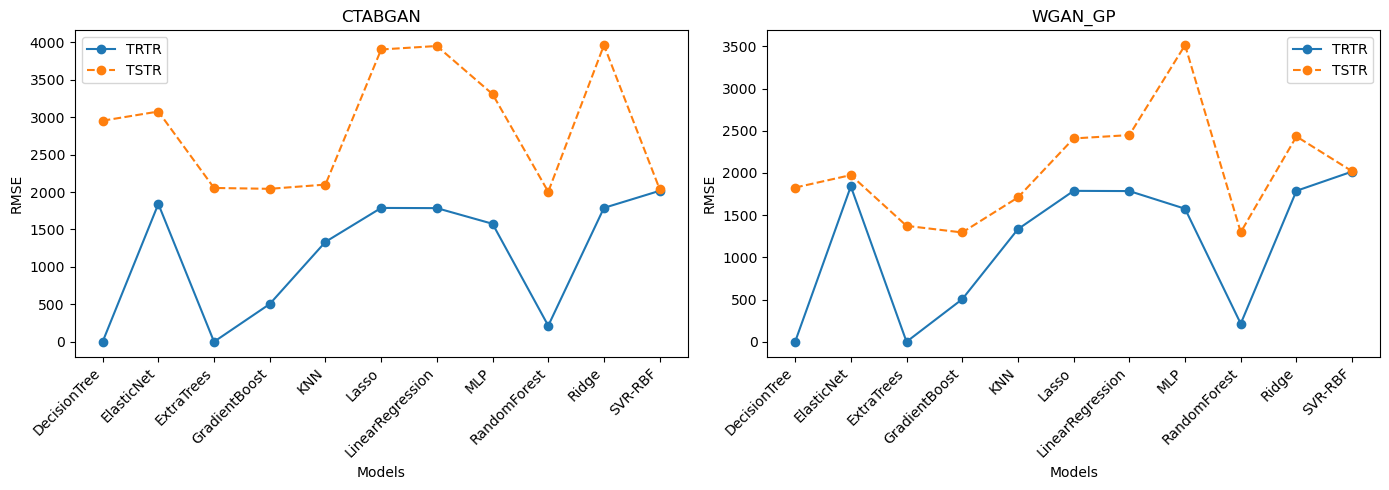

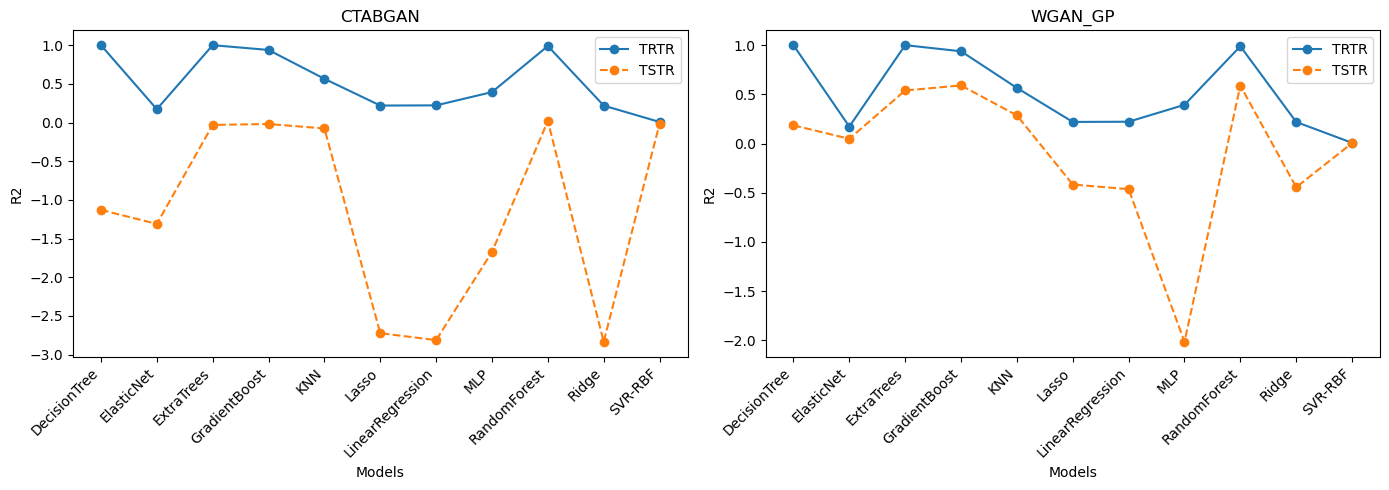

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

final_df = pd.concat(all_results, ignore_index=True)

gen_models = final_df["Synthetic"].unique()

# -------- RMSE Subplots --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()

for i, gen in enumerate(gen_models):
    subset = final_df[final_df["Synthetic"] == gen].sort_values("Model")
    x = range(len(subset["Model"]))

    axes[i].plot(x, subset["RMSE_TRTR"], marker="o", label="TRTR")
    axes[i].plot(x, subset["RMSE_TSTR"], marker="o", linestyle="--", label="TSTR")

    axes[i].set_title(gen)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(subset["Model"], rotation=45, ha="right")
    axes[i].set_xlabel("Models")
    axes[i].set_ylabel("RMSE")
    axes[i].legend()

plt.tight_layout()
plt.show()

# -------- R2 Subplots --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()

for i, gen in enumerate(gen_models):
    subset = final_df[final_df["Synthetic"] == gen].sort_values("Model")
    x = range(len(subset["Model"]))

    axes[i].plot(x, subset["R2_TRTR"], marker="o", label="TRTR")
    axes[i].plot(x, subset["R2_TSTR"], marker="o", linestyle="--", label="TSTR")

    axes[i].set_title(gen)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(subset["Model"], rotation=45, ha="right")
    axes[i].set_xlabel("Models")
    axes[i].set_ylabel("R2")
    axes[i].legend()

plt.tight_layout()
plt.show()

# 5 Statistical similarity tests 

Average feature-distribution error by model (Metro Interstate Traffic Volume)


,Model,Mean Error %,Median Error %,Std Error %
0,CTABGAN,10.002244,7.368421,19.334128
1,WGAN_GP,23.211840,2.923091,22.287039


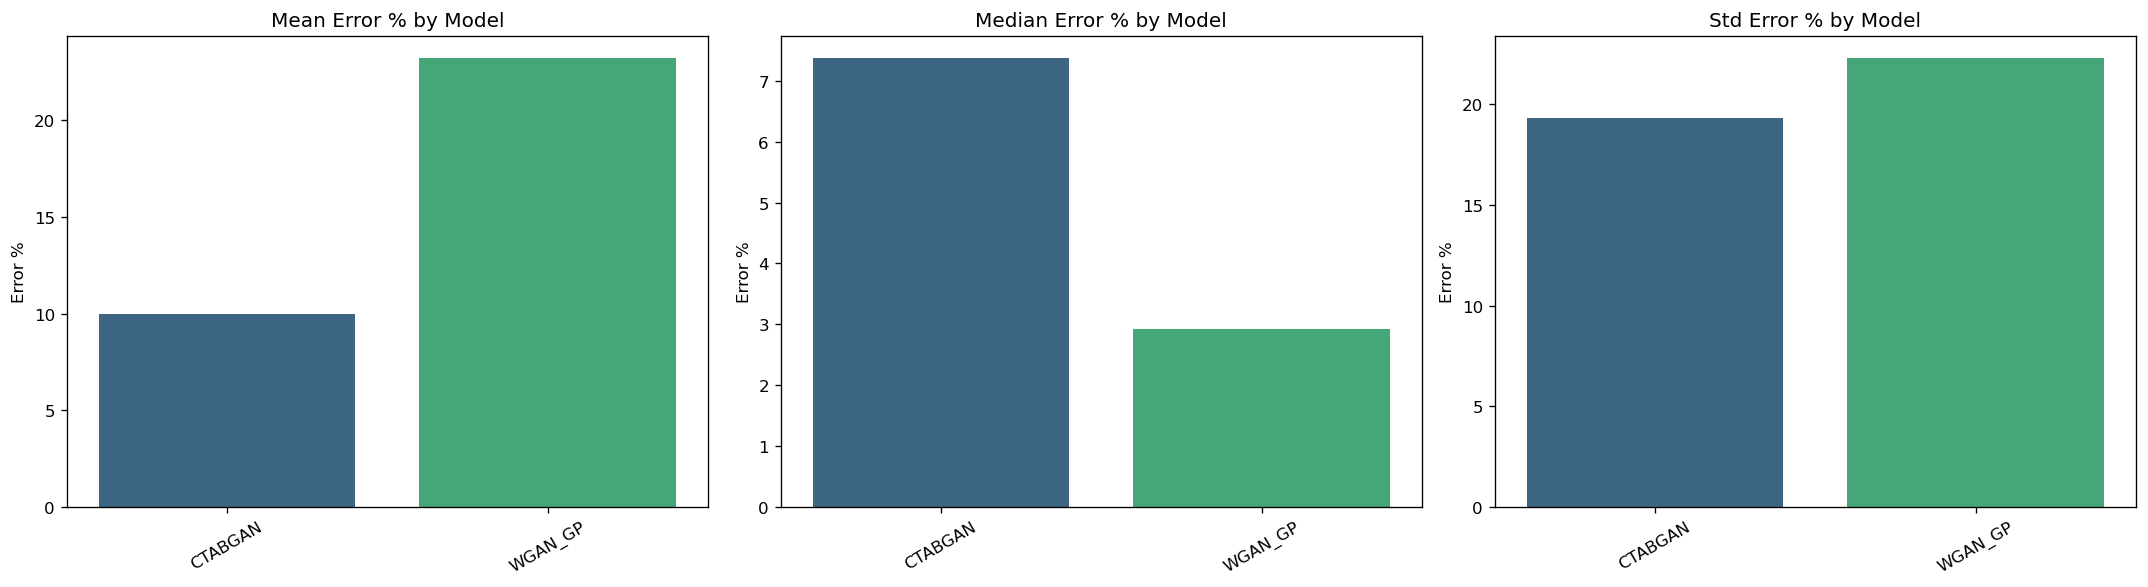

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "traffic_volume"

real_df = data.copy()

exclude_cols = {target_col}
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_cols]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    common_num_cols = [c for c in num_cols if c in synth_df.columns]

    real_num = real_df[common_num_cols].astype(np.float64)
    synth_num = synth_df[common_num_cols].astype(np.float64)

    real_means = real_num.mean()
    synth_means = synth_num.mean()

    real_stds = real_num.std(ddof=1)
    synth_stds = synth_num.std(ddof=1)

    mean_error_pct = (
        np.abs(synth_means - real_means) /
        real_means.replace(0, np.nan).abs()
    ) * 100

    std_error_pct = (
        np.abs(synth_stds - real_stds) /
        real_stds.replace(0, np.nan).abs()
    ) * 100

    feature_error_df = pd.DataFrame({
        "Feature": common_num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    summary_rows.append({
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    })

    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average feature-distribution error by model (Metro Interstate Traffic Volume)")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(
    data=summary_df,
    x="Model",
    y="Mean Error %",
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=summary_df,
    x="Model",
    y="Median Error %",
    ax=axes[1],
    palette="viridis"
)
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(
    data=summary_df,
    x="Model",
    y="Std Error %",
    ax=axes[2],
    palette="viridis"
)
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

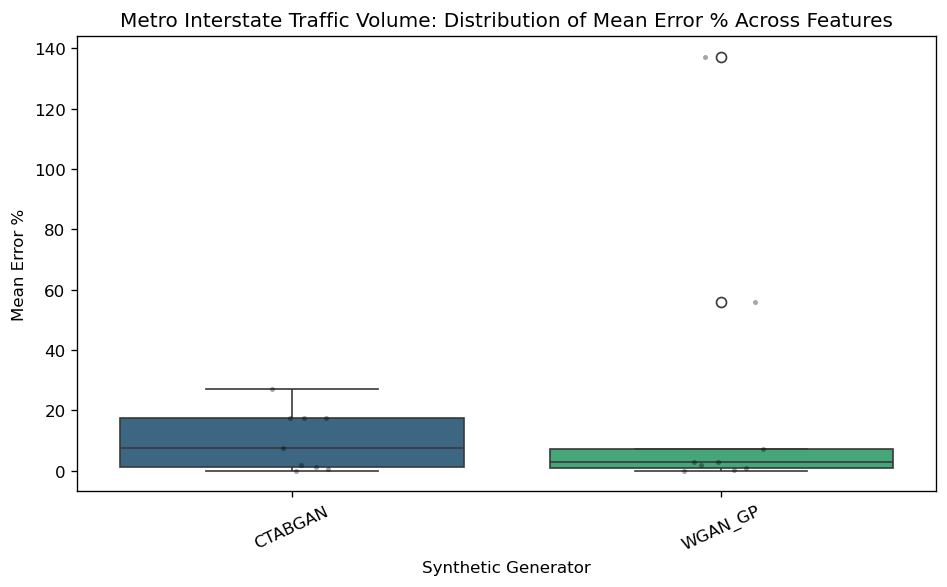

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_order
        if m in feature_error_by_model
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(8, 5), dpi=120)

sns.boxplot(
    data=dist_df,
    x="Model",
    y="Mean_Error_%",
    order=model_order,
    palette="viridis"
)

sns.stripplot(
    data=dist_df,
    x="Model",
    y="Mean_Error_%",
    order=model_order,
    color="black",
    alpha=0.35,
    size=3
)

plt.title("Metro Interstate Traffic Volume: Distribution of Mean Error % Across Features")
plt.xlabel("Synthetic Generator")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

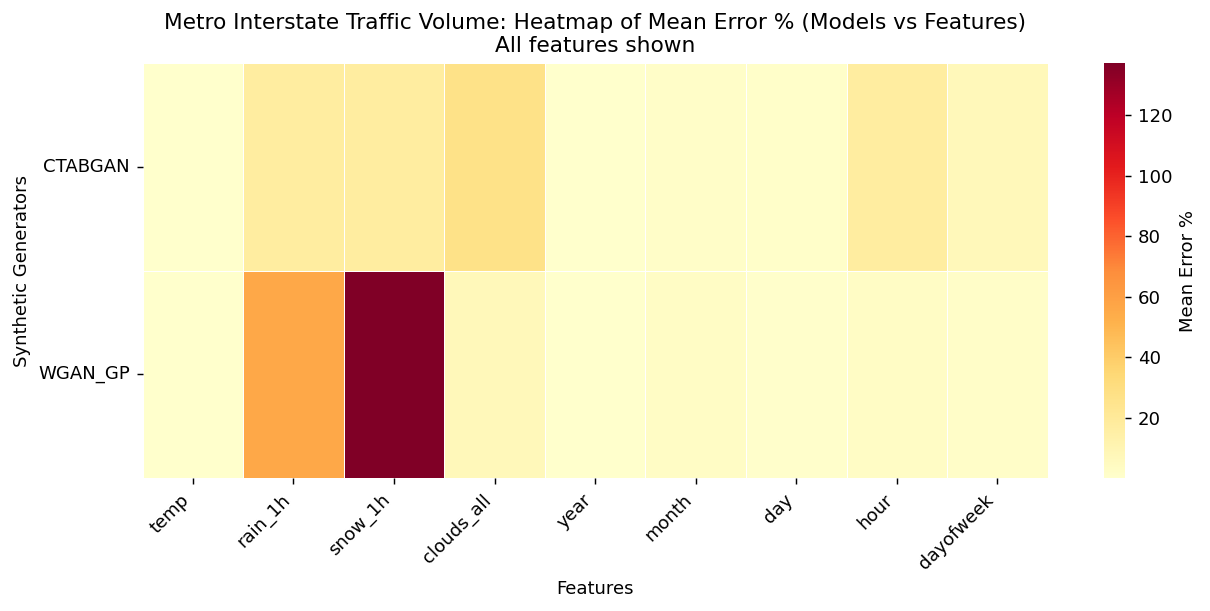

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20

if heatmap_df.shape[1] > max_features:
    top_features = (
        heatmap_df
        .mean(axis=0, skipna=True)
        .sort_values(ascending=False)
        .head(max_features)
        .index
    )
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [
    truncate_label(c, max_len=18)
    for c in heatmap_plot_df.columns
]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)

sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(
    "Metro Interstate Traffic Volume: Heatmap of Mean Error % "
    f"(Models vs Features)\n{truncated_note}"
)
plt.xlabel("Features")
plt.ylabel("Synthetic Generators")
plt.xticks(
    np.arange(len(display_labels)) + 0.5,
    display_labels,
    rotation=45,
    ha="right"
)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

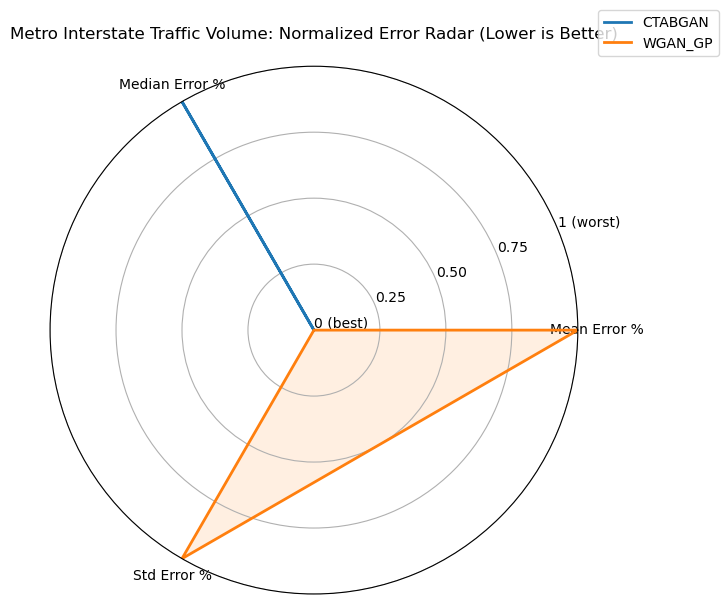

,Model,Mean Error %,Median Error %,Std Error %
0,CTABGAN,0.0,1.0,0.0
1,WGAN_GP,1.0,0.0,1.0


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
model_order = ["CTABGAN", "WGAN_GP"]

radar_df = summary_df[["Model"] + metrics].copy()
radar_df = (
    radar_df
    .set_index("Model")
    .reindex(model_order)
    .dropna(how="all")
    .reset_index()
)

norm_df = radar_df.copy()

for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()

    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics

angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw=dict(polar=True)
)

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.12
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title(
    "Metro Interstate Traffic Volume: Normalized Error Radar "
    "(Lower is Better)",
    pad=20
)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))

plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,CTABGAN,3.777778,0.0,32.0
1,WGAN_GP,10.888889,8.0,23.0


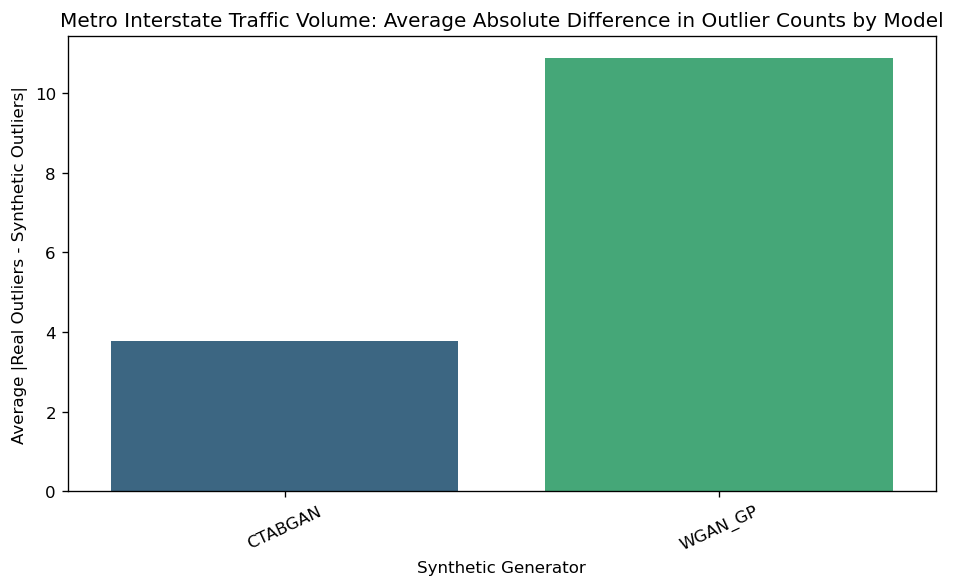

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "traffic_volume"

real_df = data.copy()

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [
    c for c in num_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr

    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {
    c: outlier_count_iqr(real_df[c])
    for c in num_cols
}

for model in model_order:
    synth_df = synthetic_outputs[model].copy()

    common_num_cols = [c for c in num_cols if c in synth_df.columns]

    synth_outliers = {
        c: outlier_count_iqr(synth_df[c])
        for c in common_num_cols
    }

    feat_df = pd.DataFrame({
        "Feature": common_num_cols,
        "Real_Outliers": [real_outliers[c] for c in common_num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in common_num_cols]
    })

    feat_df["Abs_Diff_Outlier_Count"] = (
        feat_df["Real_Outliers"] -
        feat_df["Synthetic_Outliers"]
    ).abs()

    feature_diff_by_model[model] = feat_df

    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].mean()),
        "Median_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].median()),
        "Max_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].max())
    })

outlier_summary_df = (
    pd.DataFrame(rows)
    .set_index("Model")
    .reindex(model_order)
    .reset_index()
)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)

sns.barplot(
    data=outlier_summary_df,
    x="Model",
    y="Avg_Abs_Diff_Outlier_Count",
    order=model_order,
    palette="viridis"
)

plt.title("Metro Interstate Traffic Volume: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Synthetic Generator")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [34]:
from numpy.linalg import norm
import numpy as np
import pandas as pd

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [
    c for c in num_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

real_matrix = normalize_rows(
    data[num_cols].to_numpy(dtype=np.float64)
)

for model_name in model_order:
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_df = synthetic_outputs[model_name].copy()

    common_num_cols = [c for c in num_cols if c in synth_df.columns]

    real_matrix_common = normalize_rows(
        data[common_num_cols].to_numpy(dtype=np.float64)
    )

    synth_matrix = normalize_rows(
        synth_df[common_num_cols].to_numpy(dtype=np.float64)
    )

    cosine_matrix = real_matrix_common @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i + 1}" for i in range(n)],
        columns=[f"S{j + 1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df

    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTABGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.999477  0.999317  0.999404  0.999015  0.999368  0.999022  0.999977   
R2   0.999445  0.999346  0.999419  0.999056  0.999344  0.999005  0.999934   
R3   0.999830  0.999775  0.999833  0.999605  0.999823  0.999580  0.999847   
R4   0.999897  0.999937  0.999912  0.999985  0.999923  0.999927  0.999035   
R5   0.999951  0.999827  0.999936  0.999838  0.999861  0.999918  0.999439   
R6   0.999924  0.999976  0.999940  0.999937  0.999978  0.999856  0.999339   
R7   0.999931  0.999942  0.999989  0.999958  0.999948  0.999924  0.999301   
R8   0.999404  0.999260  0.999411  0.998993  0.999308  0.999004  0.999898   
R9   0.999381  0.999263  0.999395  0.998994  0.999285  0.998972  0.999861   
R10  0.999385  0.999392  0.999388  0.999036  0.999390  0.998891  0.999963   

           S8        S9       S10  
R1   0.999058  0.998862  0.999085  
R2   0.999045  0.999005  0.9

,avg_cosine,max_cosine
CTABGAN,0.999586,1.000000
WGAN_GP,0.999593,0.999999


In [35]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [
        c for c in num_cols
        if c not in ["ID", "Diabetes_binary", target_col]
    ]

    common_num_cols = [c for c in num_cols if c in synthetic_data.columns]

    R = real_data[common_num_cols].to_numpy(dtype=np.float64)
    S = synthetic_data[common_num_cols].to_numpy(dtype=np.float64)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name in model_order:
    synth_df = synthetic_outputs[name].copy()

    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(
        data,
        synth_df
    )

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")

    for rank, i in enumerate(top_idx, 1):
        print(
            f"{rank:02d}. R{i + 1} -> S{best_indices[i] + 1}   "
            f"cosine similarity = {best_sims[i]:.4f}"
        )


CTABGAN - Top 10 Real -> Synthetic Matchings
01. R953 -> S831   cosine similarity = 1.0000
02. R450 -> S69   cosine similarity = 1.0000
03. R146 -> S855   cosine similarity = 1.0000
04. R956 -> S314   cosine similarity = 1.0000
05. R705 -> S490   cosine similarity = 1.0000
06. R854 -> S584   cosine similarity = 1.0000
07. R486 -> S415   cosine similarity = 1.0000
08. R295 -> S496   cosine similarity = 1.0000
09. R170 -> S781   cosine similarity = 1.0000
10. R845 -> S983   cosine similarity = 1.0000

WGAN_GP - Top 10 Real -> Synthetic Matchings
01. R979 -> S127   cosine similarity = 1.0000
02. R210 -> S984   cosine similarity = 1.0000
03. R726 -> S320   cosine similarity = 1.0000
04. R220 -> S747   cosine similarity = 1.0000
05. R883 -> S318   cosine similarity = 1.0000
06. R191 -> S718   cosine similarity = 1.0000
07. R324 -> S916   cosine similarity = 1.0000
08. R841 -> S143   cosine similarity = 1.0000
09. R537 -> S831   cosine similarity = 1.0000
10. R886 -> S963   cosine similarit

In [36]:
# Hungarian Mapping (Cosine) - Metro Interstate Traffic Volume setup

import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def normalize_rows(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols=None
) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    num_cols = [
        c for c in num_cols
        if c not in ["ID", "Diabetes_binary", target_col]
    ]

    common_num_cols = [c for c in num_cols if c in synth_df.columns]

    R = real_df[common_num_cols].to_numpy(dtype=np.float64)
    S = synth_df[common_num_cols].to_numpy(dtype=np.float64)

    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    num_cols=None
):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())

    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()
results = {}

for name in model_order:
    synth_df = synthetic_outputs[name].copy()

    print("\n==============================")
    print(
        f"{name}: Hungarian matching "
        f"(cosine, numeric features excluding ID, Diabetes_binary, and {target_col})"
    )
    print("==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(
        real_df,
        synth_df
    )

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))

    for r in range(top_k):
        k = order[r]
        print(
            f"R{row_ind[k] + 1} <-> S{col_ind[k] + 1}   "
            f"cosine similarity = {sims[k]:.4f}"
        )


CTABGAN: Hungarian matching (cosine, numeric features excluding ID, Diabetes_binary, and traffic_volume)
Average cosine similarity (Hungarian match): 0.9999

R953 <-> S831   cosine similarity = 1.0000
R450 <-> S69   cosine similarity = 1.0000
R146 <-> S855   cosine similarity = 1.0000
R705 <-> S490   cosine similarity = 1.0000
R854 <-> S584   cosine similarity = 1.0000
R301 <-> S272   cosine similarity = 1.0000
R471 <-> S238   cosine similarity = 1.0000
R359 <-> S212   cosine similarity = 1.0000
R31 <-> S114   cosine similarity = 1.0000
R520 <-> S261   cosine similarity = 1.0000

WGAN_GP: Hungarian matching (cosine, numeric features excluding ID, Diabetes_binary, and traffic_volume)
Average cosine similarity (Hungarian match): 1.0000

R883 <-> S318   cosine similarity = 1.0000
R886 <-> S963   cosine similarity = 1.0000
R138 <-> S251   cosine similarity = 1.0000
R18 <-> S531   cosine similarity = 1.0000
R262 <-> S87   cosine similarity = 1.0000
R99 <-> S783   cosine similarity = 1.0000

In [37]:
import pandas as pd
import numpy as np

target_col = "traffic_volume"

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in feature_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

synth_source = synthetic_outputs

model_order = ["CTABGAN", "WGAN_GP"]
output_file = "Matchings_CTABGAN_WGAN_GP_Metro_Interstate_Traffic.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results or model_name not in synth_source:
            continue

        model_res = results[model_name]

        # Supports:
        # A) Hungarian results: row_ind/col_ind + similarities/distances
        # B) Best-match results: best_indices/best_sims
        if "row_ind" in model_res and "col_ind" in model_res:
            row_ind = np.asarray(model_res["row_ind"])
            col_ind = np.asarray(model_res["col_ind"])

            if "similarities" in model_res:
                score_key = "cosine_similarity"
                scores = np.asarray(model_res["similarities"])
            elif "distances" in model_res:
                score_key = "mahalanobis_distance"
                scores = np.asarray(model_res["distances"])
            else:
                raise KeyError(
                    f"No score array found for model {model_name}. "
                    "Expected 'similarities' or 'distances'."
                )

        elif "best_indices" in model_res and "best_sims" in model_res:
            row_ind = np.arange(len(model_res["best_indices"]))
            col_ind = np.asarray(model_res["best_indices"])
            score_key = "cosine_similarity"
            scores = np.asarray(model_res["best_sims"])

        else:
            raise KeyError(
                f"Unsupported results format for model {model_name}. "
                "Expected Hungarian keys or best-match keys."
            )

        synth_df = synth_source[model_name].copy()

        common_feature_cols = [
            c for c in feature_cols
            if c in synth_df.columns
        ]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i + 1}" for i in row_ind],
            "synthetic_label": [f"S{j + 1}" for j in col_ind],
            score_key: scores
        })

        real_part = real_df.iloc[row_ind][common_feature_cols].reset_index(drop=True)
        real_part.insert(0, "label", [f"R{i + 1}" for i in row_ind])

        synth_part = synth_df.iloc[col_ind][common_feature_cols].reset_index(drop=True)
        synth_part.insert(0, "label", [f"S{j + 1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        side_by_side.to_excel(
            writer,
            sheet_name=model_name[:31],
            index=False
        )

        combined_rows.append(side_by_side)

        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(scores),
            f"Avg_{score_key}": float(np.mean(scores)),
            f"Median_{score_key}": float(np.median(scores)),
            f"Min_{score_key}": float(np.min(scores)),
            f"Max_{score_key}": float(np.max(scores)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(
            writer,
            sheet_name="All_Models_Combined",
            index=False
        )

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        sort_col = [c for c in summary_df.columns if c.startswith("Avg_")][0]
        ascending = False if "cosine" in sort_col else True

        summary_df = summary_df.sort_values(
            sort_col,
            ascending=ascending
        )

        summary_df.to_excel(
            writer,
            sheet_name="Summary",
            index=False
        )

print(f"Saved: {output_file}")
display(summary_df)

Saved: Matchings_CTABGAN_WGAN_GP_Metro_Interstate_Traffic.xlsx


,Model,Num_Matches,Avg_cosine_similarity,Median_cosine_similarity,Min_cosine_similarity,Max_cosine_similarity
1,WGAN_GP,1000,0.999962,0.999972,0.999434,0.999999
0,CTABGAN,1000,0.999934,0.999987,0.999435,1.000000


# 7. Mahalanobis distance with Hungrain Mapping  

In [38]:
import numpy as np
from numpy.linalg import inv, LinAlgError

target_col = "traffic_volume"

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)

    if cov.ndim == 0:
        cov = np.array([[cov]])

    p = cov.shape[0]

    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))

    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [
    c for c in num_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

if not num_cols:
    raise ValueError("No numeric feature columns found after excluding target.")

data_numeric = data[num_cols].dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=np.float64)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)

print("Fitted mean and inverse covariance on real Metro feature data.")
print(f"Used features excluding target: {len(num_cols)}")
print(f"Mean shape: {mu_real.shape}")
print(f"Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real Metro feature data.
Used features excluding target: 9
Mean shape: (9,)
Inv_cov shape: (9, 9)


In [39]:
import numpy as np
import pandas as pd

mahalanobis_results = {}
target_col = "traffic_volume"

model_order = ["CTABGAN", "WGAN_GP"]

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [
    c for c in num_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

for name in model_order:
    synth_df = synthetic_outputs[name].copy()

    common_num_cols = [c for c in num_cols if c in synth_df.columns]

    synth_numeric = synth_df[common_num_cols].to_numpy(dtype=np.float64)

    dists = mahalanobis_distances_to_distribution(
        synth_numeric,
        mu_real,
        inv_cov_real
    )

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [
        r["mean"],
        r["median"],
        r["std"],
        r["min"],
        r["max"]
    ]
    for name, r in mahalanobis_results.items()
}, index=[
    "mean_dist",
    "median_dist",
    "std_dist",
    "min_dist",
    "max_dist"
]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real Metro distribution (lower is better):")
display(summary)

Mahalanobis distance to real Metro distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
WGAN_GP,2.463226,2.361267,0.708122,0.741087,5.739060
CTABGAN,2.699548,2.671838,0.631621,1.140919,6.782866


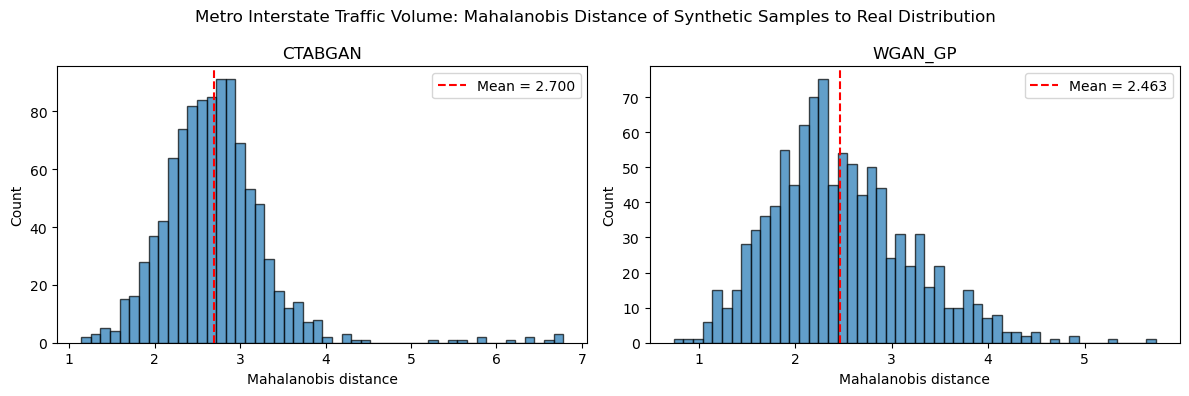

In [40]:
import os
import matplotlib.pyplot as plt

n_models = len(mahalanobis_results)

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))

if n_models == 1:
    axes = [axes]
else:
    axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(
        res["distances"],
        bins=50,
        edgecolor="black",
        alpha=0.7
    )

    ax.axvline(
        res["mean"],
        color="red",
        linestyle="--",
        label=f"Mean = {res['mean']:.3f}"
    )

    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle(
    "Metro Interstate Traffic Volume: Mahalanobis Distance of Synthetic Samples to Real Distribution",
    fontsize=12
)

plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)

plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_metro_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [41]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(
        real_matrix,
        synth_matrix,
        metric="mahalanobis",
        VI=inv_cov
    )

hungarian_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [
    c for c in num_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

# Fixed sample from real data
real_full = data[num_cols].to_numpy(dtype=np.float64)

n_sample = min(2000, len(real_full))
rng = np.random.default_rng(42)

real_idx = rng.choice(
    len(real_full),
    size=n_sample,
    replace=False
)

real_matrix = real_full[real_idx]

for name in model_order:
    synth_df = synthetic_outputs[name].copy()

    common_num_cols = [c for c in num_cols if c in synth_df.columns]

    # Keep the same column order as the real matrix
    synth_numeric = synth_df[common_num_cols].to_numpy(dtype=np.float64)

    if synth_numeric.shape[0] >= n_sample:
        synth_numeric = synth_numeric[:n_sample]
    else:
        synth_idx = rng.choice(
            len(synth_numeric),
            size=n_sample,
            replace=True
        )
        synth_numeric = synth_numeric[synth_idx]

    D = pairwise_mahalanobis(
        real_matrix,
        synth_numeric,
        inv_cov_real
    )

    D = np.nan_to_num(
        D,
        nan=1e10,
        posinf=1e10,
        neginf=1e10
    )

    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print(
    "Metro Interstate Traffic Volume - Hungarian matching using "
    "Mahalanobis distance (lower is better):"
)

display(hungarian_summary)

Metro Interstate Traffic Volume - Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
WGAN_GP,1.410562,1.241461,1.295465,24.220249
CTABGAN,1.468671,1.307281,1.164796,24.567022


In [42]:
# Fast Greedy mapping (subsampled + vectorized)

import numpy as np
import pandas as pd

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def greedy_one_to_one_matching_fast(D):
    n_rows, n_cols = D.shape
    n_match = min(n_rows, n_cols)

    used_rows = np.zeros(n_rows, dtype=bool)
    used_cols = np.zeros(n_cols, dtype=bool)

    flat_order = np.argsort(D, axis=None)
    pairs = []

    for idx in flat_order:
        i = idx // n_cols
        j = idx % n_cols

        if not used_rows[i] and not used_cols[j]:
            used_rows[i] = True
            used_cols[j] = True
            pairs.append((i, j, float(D[i, j])))

            if len(pairs) == n_match:
                break

    distances = np.array([p[2] for p in pairs], dtype=np.float64)

    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan

    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [
    c for c in num_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

X_real_full = data[num_cols].to_numpy(dtype=np.float64)

MAX_ROWS = 2000
rng = np.random.default_rng(42)

if len(X_real_full) > MAX_ROWS:
    real_idx = rng.choice(len(X_real_full), size=MAX_ROWS, replace=False)
else:
    real_idx = np.arange(len(X_real_full))

X_real = X_real_full[real_idx]

for name in model_order:
    synth_df = synthetic_outputs[name].copy()

    common_num_cols = [c for c in num_cols if c in synth_df.columns]

    X_synth_full = synth_df[common_num_cols].to_numpy(dtype=np.float64)

    if len(X_synth_full) > MAX_ROWS:
        synth_idx = rng.choice(len(X_synth_full), size=MAX_ROWS, replace=False)
    else:
        synth_idx = np.arange(len(X_synth_full))

    X_synth = X_synth_full[synth_idx]

    D = pairwise_mahalanobis(
        X_real,
        X_synth,
        inv_cov_real
    )

    D = np.nan_to_num(
        D,
        nan=1e10,
        posinf=1e10,
        neginf=1e10
    )

    total_g, mean_g, _ = greedy_one_to_one_matching_fast(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Rows_Used_For_Greedy": int(min(len(X_real), len(X_synth))),
        "Greedy total (sampled)": total_g,
        "Hungarian total (sampled)": h_total,
        "Greedy mean (sampled)": mean_g,
        "Hungarian mean (sampled)": h_mean,
        "Total diff": total_g - h_total,
        "Mean diff": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [
        greedy_results[name]["total_distance"],
        greedy_results[name]["mean_distance"]
    ]
    for name in greedy_results
}, index=[
    "total_distance",
    "mean_distance"
]).T

greedy_summary.index.name = "Model"

print("Metro Interstate Traffic Volume - Greedy one-to-one matching (fast sampled version):")
display(greedy_summary)

print("\nComparison table:")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Metro Interstate Traffic Volume - Greedy one-to-one matching (fast sampled version):


,total_distance,mean_distance
Model,,
CTABGAN,1607.388699,1.607389
WGAN_GP,1498.571923,1.498572



Comparison table:


,Rows_Used_For_Greedy,Greedy total (sampled),Hungarian total (sampled),Greedy mean (sampled),Hungarian mean (sampled),Total diff,Mean diff
Model,,,,,,,
CTABGAN,1000,1607.388699,1468.671147,1.607389,1.468671,138.717552,0.138718
WGAN_GP,1000,1498.571923,1410.562021,1.498572,1.410562,88.009902,0.088010


In [43]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)

    return cdist(
        R,
        S,
        metric="mahalanobis",
        VI=inv_cov_real
    )

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(
        real_df,
        synth_df,
        feature_cols,
        inv_cov_real
    )

    D = np.nan_to_num(
        np.asarray(D, dtype=np.float64),
        nan=1e10,
        posinf=1e10,
        neginf=1e10
    )

    n_real, n_synth = D.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]

    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in feature_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(
    cov_real + 1e-6 * np.eye(cov_real.shape[0])
)

mahalanobis_results = {}

for name in model_order:
    synth_df = synthetic_outputs[name].copy()

    common_feature_cols = [
        c for c in feature_cols
        if c in synth_df.columns
    ]

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=common_feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 9
CTABGAN: avg matched Mahalanobis distance = 1.4687
WGAN_GP: avg matched Mahalanobis distance = 1.4106


In [46]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)

    return cdist(
        R,
        S,
        metric="mahalanobis",
        VI=inv_cov_real
    )

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(
        real_df,
        synth_df,
        feature_cols,
        inv_cov_real
    )

    D = np.nan_to_num(
        np.asarray(D, dtype=np.float64),
        nan=1e10,
        posinf=1e10,
        neginf=1e10
    )

    n_real, n_synth = D.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]

    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in feature_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

# Keep only features available in every synthetic output
for name in model_order:
    missing = [c for c in feature_cols if c not in synthetic_outputs[name].columns]
    if missing:
        raise ValueError(f"{name} is missing columns needed for Mahalanobis: {missing}")

print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)

inv_cov_real = np.linalg.pinv(
    cov_real + 1e-6 * np.eye(cov_real.shape[0])
)

mahalanobis_results = {}

for name in model_order:
    synth_df = synthetic_outputs[name].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist,
        "distance_matrix": D
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 9
CTABGAN: avg matched Mahalanobis distance = 1.4687
WGAN_GP: avg matched Mahalanobis distance = 1.4106


In [47]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in feature_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

# Ensure both synthetic outputs contain the same feature columns
for model_name in model_order:
    missing = [
        c for c in feature_cols
        if c not in synthetic_outputs[model_name].columns
    ]

    if missing:
        raise ValueError(
            f"{model_name} is missing columns needed for Mahalanobis: {missing}"
        )

real_df = data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

cov_real = np.cov(X_real, rowvar=False)

inv_cov_real = np.linalg.pinv(
    cov_real + 1e-6 * np.eye(cov_real.shape[0])
)

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float64)

    D = cdist(
        X_real,
        X_synth,
        metric="mahalanobis",
        VI=inv_cov_real
    )

    D = np.nan_to_num(
        D,
        nan=1e10,
        posinf=1e10,
        neginf=1e10
    )

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]

    r_to_match = {
        r: (s, d)
        for r, s, d in zip(row_ind, col_ind, dists)
    }

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")

    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r + 1} -> S{s + 1}   distance = {dist:.4f}")
        else:
            print(f"R{r + 1} -> No match found")


CTABGAN - Hungarian mappings for R1 to R20:
R1 -> S204   distance = 1.0781
R2 -> S81   distance = 1.3375
R3 -> S790   distance = 1.5439
R4 -> S125   distance = 1.0240
R5 -> S497   distance = 1.2648
R6 -> S724   distance = 0.6478
R7 -> S217   distance = 0.8243
R8 -> S458   distance = 2.6795
R9 -> S600   distance = 2.1344
R10 -> S913   distance = 1.0057
R11 -> S639   distance = 0.8826
R12 -> S585   distance = 1.4435
R13 -> S437   distance = 1.4519
R14 -> S861   distance = 1.7348
R15 -> S336   distance = 1.3963
R16 -> S532   distance = 0.7679
R17 -> S307   distance = 1.2376
R18 -> S79   distance = 2.0742
R19 -> S923   distance = 1.2081
R20 -> S117   distance = 0.8813

WGAN_GP - Hungarian mappings for R1 to R20:
R1 -> S836   distance = 0.8354
R2 -> S388   distance = 1.3065
R3 -> S434   distance = 1.1440
R4 -> S318   distance = 0.8195
R5 -> S23   distance = 0.9540
R6 -> S486   distance = 1.1444
R7 -> S145   distance = 0.6597
R8 -> S566   distance = 1.1550
R9 -> S570   distance = 1.8000
R10

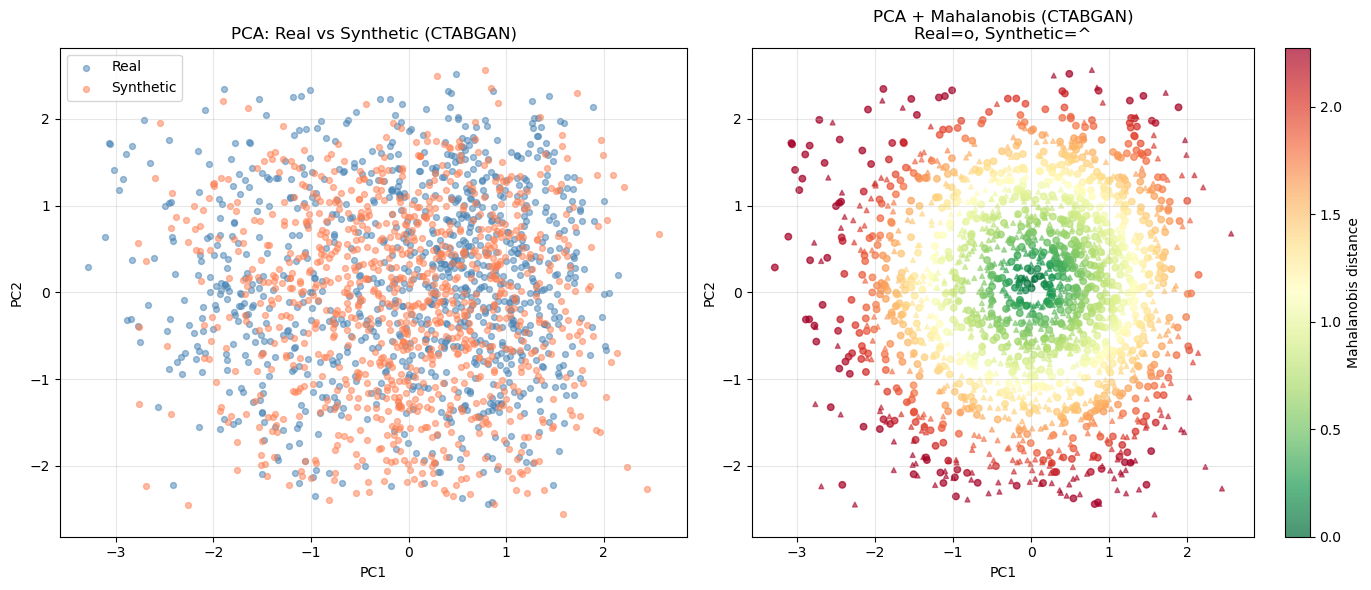

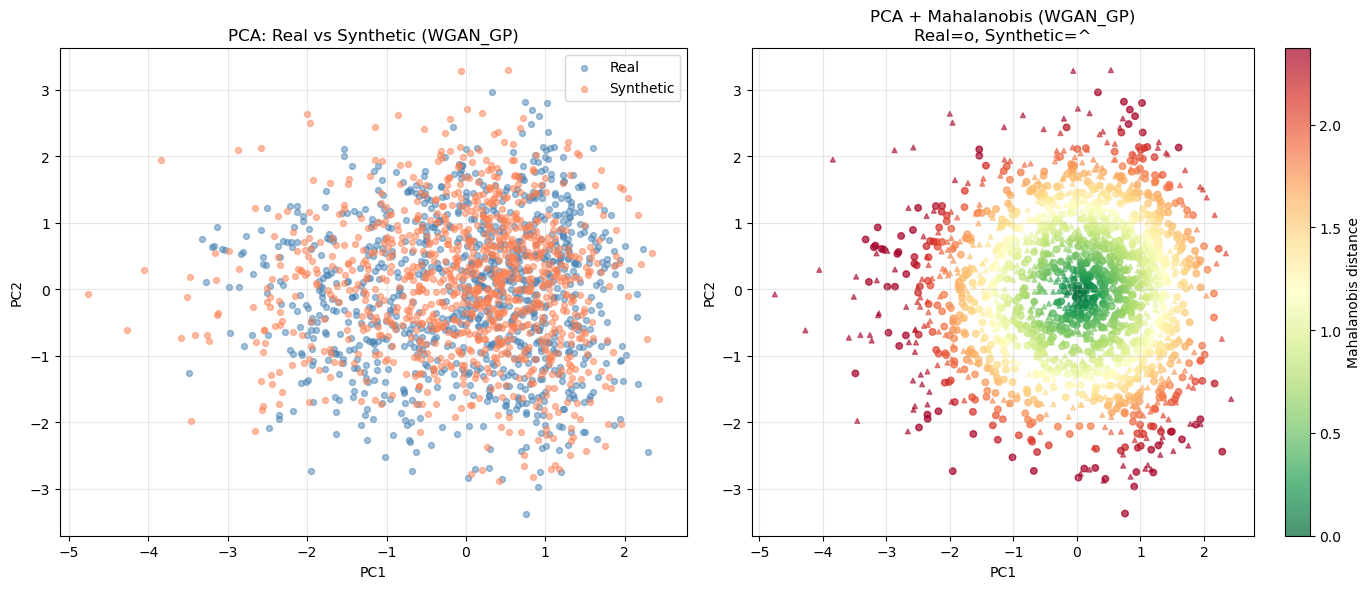

Metro Interstate Traffic Volume - PCA + Mahalanobis summary:


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
1,WGAN_GP,1.278998,1.198161,-0.080836
0,CTABGAN,1.287481,1.223886,-0.063594


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

target_col = "traffic_volume"

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(
        np.maximum(
            np.einsum("ij,jk,ik->i", delta, inv_cov, delta),
            0.0
        )
    )

model_order = ["CTABGAN", "WGAN_GP"]

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in feature_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

for model_name in model_order:
    missing = [
        c for c in feature_cols
        if c not in synthetic_outputs[model_name].columns
    ]

    if missing:
        raise ValueError(
            f"{model_name} is missing columns needed for PCA/Mahalanobis: {missing}"
        )

X_r = real_df[feature_cols].to_numpy(dtype=np.float64)

scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    X_s = synth_df[feature_cols].to_numpy(dtype=np.float64)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])

    Z_all = PCA(
        n_components=2,
        random_state=42
    ).fit_transform(X_all)

    n_r = len(X_r_s)

    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)

    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]

    ax.scatter(
        Z_r[:, 0],
        Z_r[:, 1],
        c="steelblue",
        alpha=0.5,
        s=18,
        label="Real"
    )

    ax.scatter(
        Z_s[:, 0],
        Z_s[:, 1],
        c="coral",
        alpha=0.5,
        s=18,
        label="Synthetic"
    )

    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]

    vmax = np.percentile(
        np.hstack([d_r, d_s]),
        95
    )

    sc = ax.scatter(
        Z_r[:, 0],
        Z_r[:, 1],
        c=d_r,
        cmap="RdYlGn_r",
        alpha=0.7,
        s=22,
        marker="o",
        vmin=0,
        vmax=vmax
    )

    ax.scatter(
        Z_s[:, 0],
        Z_s[:, 1],
        c=d_s,
        cmap="RdYlGn_r",
        alpha=0.55,
        s=12,
        marker="^",
        vmin=0,
        vmax=vmax
    )

    plt.colorbar(
        sc,
        ax=ax,
        label="Mahalanobis distance"
    )

    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=o, Synthetic=^")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")

print("Metro Interstate Traffic Volume - PCA + Mahalanobis summary:")
display(summary_df)

In [49]:
# print results on excel sheets

import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_outputs: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_CTABGAN_WGAN_GP_Metro.xlsx"
):
    dataset_name = "Metro"
    model_order = ["CTABGAN", "WGAN_GP"]
    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_outputs or model_name not in hungarian_results:
                continue

            synth_df = synthetic_outputs[model_name].copy()

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            common_num_cols = [
                c for c in num_cols
                if c in synth_df.columns
            ]

            records = []

            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i) + 1}",
                    "Synthetic_Label": f"S{int(s_i) + 1}",
                    "Mahalanobis_Distance": float(dist),
                }

                for c in common_num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]

                records.append(rec)

            matched_df = pd.DataFrame(records)

            sheet_name = f"{dataset_name}_{model_name}"[:31]
            matched_df.to_excel(
                writer,
                sheet_name=sheet_name,
                index=False
            )

            summary_rows.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = (
                pd.DataFrame(summary_rows)
                .sort_values("Mean_Distance")
            )

            summary_df.to_excel(
                writer,
                sheet_name=f"{dataset_name}_Summary",
                index=False
            )

    print(f"Excel file created: {filename}")

# ---- Run ----
target_col = "traffic_volume"

real_df = data.copy()

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [
    c for c in num_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_outputs=synthetic_outputs,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_CTABGAN_WGAN_GP_Metro.xlsx"
)


Excel file created: Hungarian_Mahalanobis_CTABGAN_WGAN_GP_Metro.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [51]:
# MIA with ML regression model

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample_regression(model, X, y):
    y_pred = model.predict(X)

    # Per-sample squared error as attack signal:
    # lower loss => more likely member
    return (y - y_pred) ** 2

def privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)

    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample_regression(
        model,
        X_train_s,
        y_train
    )

    loss_test = model_loss_per_sample_regression(
        model,
        X_test_s,
        y_test
    )

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([
        np.ones(len(loss_train)),
        np.zeros(len(loss_test))
    ])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(
        fpr,
        0.01,
        side="right"
    ) - 1

    idx_fpr_001 = max(0, idx_fpr_001)

    tpr_at_fpr_001 = (
        tpr[idx_fpr_001]
        if idx_fpr_001 < len(tpr)
        else float("nan")
    )

    return {
        "AUC": auc,
        "Advantage": advantage,
        "TPR_at_FPR_001": tpr_at_fpr_001
    }

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in feature_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

real_df = data.copy()

mia_rows = []

for synth_name in model_order:
    synth_df = synthetic_outputs[synth_name].copy()

    common_feature_cols = [
        c for c in feature_cols
        if c in synth_df.columns
    ]

    X_train = real_df[common_feature_cols].to_numpy(dtype=np.float64)
    y_train = real_df[target_col].to_numpy(dtype=np.float64)

    X_test = synth_df[common_feature_cols].to_numpy(dtype=np.float64)
    y_test = synth_df[target_col].to_numpy(dtype=np.float64)

    model = Ridge(alpha=1.0)

    metrics = privacy_metrics_mia_regression(
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    metrics["Synthetic_Model"] = synth_name
    mia_rows.append(metrics)

mia_summary_df = pd.DataFrame(mia_rows)

print("MIA regression privacy metrics:")
display(mia_summary_df)

MIA regression privacy metrics:


,AUC,Advantage,TPR_at_FPR_001,Synthetic_Model
0,0.546349,0.124,0.009,CTABGAN
1,0.409210,0.038,0.002,WGAN_GP


In [52]:
# MIA with Mahalanobis

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

target_col = "traffic_volume"
model_order = ["CTABGAN", "WGAN_GP"]

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)

    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)

    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(
        np.maximum(
            np.sum((diff_train @ cov_inv) * diff_train, axis=1),
            0.0
        )
    )

    md_test = np.sqrt(
        np.maximum(
            np.sum((diff_test @ cov_inv) * diff_test, axis=1),
            0.0
        )
    )

    scores = -np.concatenate([md_train, md_test])

    labels = np.concatenate([
        np.ones(len(md_train)),
        np.zeros(len(md_test))
    ])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(
        fpr,
        0.01,
        side="right"
    ) - 1

    idx = max(0, idx)

    tpr_at_fpr_001 = (
        tpr[idx]
        if idx < len(tpr)
        else float("nan")
    )

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in feature_cols
    if c not in ["ID", "Diabetes_binary", target_col]
]

X_train = data[feature_cols].to_numpy(dtype=np.float64)

rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    common_feature_cols = [
        c for c in feature_cols
        if c in synth_df.columns
    ]

    X_train_common = data[common_feature_cols].to_numpy(dtype=np.float64)
    X_test = synth_df[common_feature_cols].to_numpy(dtype=np.float64)

    m = privacy_metrics_mia_mahalanobis(
        X_train_common,
        X_test
    )

    m["Model"] = model_name
    rows.append(m)

comparison_df = (
    pd.DataFrame(rows)[
        [
            "Model",
            "AUC",
            "Advantage",
            "TPR_at_FPR_001",
            "Train_MD_Mean",
            "Test_MD_Mean"
        ]
    ]
    .sort_values("AUC", ascending=False)
    .reset_index(drop=True)
)

print("Metro Interstate Traffic Volume - MIA (Mahalanobis) comparison across synthetic models:")
display(comparison_df)

Metro Interstate Traffic Volume - MIA (Mahalanobis) comparison across synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CTABGAN,0.520665,0.061,0.004,2.737128,2.699575
1,WGAN_GP,0.393968,0.046,0.000,2.737128,2.463306
